In [ ]:
# Import functions from preprocessing.py
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.optim as optim
from tqdm import tqdm

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked


# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))

result = {}
B = 169
n_i = 6
seed = 4
input_dim = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

niter_GP=10
niter_GPAreal=10
niter_VI= 50

# Load data from the specified path
data_path = os.path.join('..', 'data','beta', f'B_{B}_n_{n_i}', f'data_seed_{seed}.pt')
data = torch.load(data_path)

# Extract variables from the data dictionary
y = data['y']
region_assignments = data['region_assignments']
x = data['x']
w = data['w']
e = data['e']
s = data['s']
x_jumbled_within_regions = data['x_jumbled_within_regions']
s_jumbled_within_regions = data['s_jumbled_within_regions']
perm_matrix_x = data['perm_matrix_x']
perm_matrix_s = data['perm_matrix_s']
sigmasq_true = data['sigmasq_true']
phi_true = data['phi_true']
beta_true = data['beta_true']
nu_true = data['nu_true']
tausq_true = data['tausq_true']


# Train the GPmodel (oracle)
# Oracle GP model if the locations and links are known
# Initialize and optimize the model
model = GPModel().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(niter_GP)):
    optimizer.zero_grad()
    loss = model(s, x, y)
    loss.backward()
    optimizer.step()
    
    # Constrain sigmasq, length_scale, and tausq to be positive
    with torch.no_grad():
        model.sigmasq.clamp_(min=1e-6)
        model.phi.clamp_(min=1e-6)
        model.tausq.clamp_(min=1e-6)
        
# Save the model parameters
model_params = {
    'nu': model.nu.item(),
    'phi': model.phi.item(),
    'sigmasq': model.sigmasq.item(),
    'tausq': model.tausq.item(),
    'beta': model.beta.detach().cpu().numpy()
}

# Save the model parameters to a file
result['GPmodel'] = model_params


# Train the model GPareal
# Compute region-wise averages directly
unique_regions = torch.unique(region_assignments)
B = len(unique_regions)

ybar = torch.zeros(B, device=y.device)
xbar = torch.zeros(B, input_dim, device=x.device)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Compute region-wise averages for y and x
    ybar[i] = torch.mean(y[indices])
    xbar[i] = torch.mean(x_jumbled_within_regions[indices], dim=0)


# Initialize and optimize the model
model = GPArealModel().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(niter_GPAreal)):
    optimizer.zero_grad()
    loss = model(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    optimizer.step()


# Save the model parameters
model_params = {
    'nu': model.nu.item(),
    'phi': model.phi.item(),
    'sigmasq': model.sigmasq.item(),
    'tausq': model.tausq.item(),
    'beta': model.beta.detach().cpu().numpy()
}
# Save the model parameters to a file
result['GPArealModel'] = model_params


# Train the model VIGP_unlinked
n_blocks = B
n_locations = n_i

# Random toy data for X and Y
X = torch.tensor(x_jumbled_within_regions, dtype=torch.float32).reshape(n_blocks, n_locations)
Y = torch.tensor(y, dtype=torch.float32).reshape(n_blocks, n_locations)

# Generate (n_blocks * n_locations) 2D coordinates
total_points = n_blocks * n_locations
locations = torch.tensor(s_jumbled_within_regions,dtype=torch.float32)

# Compute distance matrix from locations
Dist = torch.cdist(locations, locations, p=2)  # Pairwise distances
Dist = (Dist + Dist.T) / 2  # Make it symmetric because numerical errors can cause asymmetry

# Set optional args
n_steps = 50
n_phi_samples = 100
n_piX_sample = 50
tau_X = 0.8
tau_S = 0.8
n_piS_sample = 50

#informative prior
# prior_parameters = {
#     "a1": 490,
#     "b1": (490-1)*result['GPArealModel']['sigmasq'],
#     "a2": 490,  # Using the previous entry
#     "b2": (490-1)*result['GPArealModel']['tausq'],
#     "eta_X_sq": 0.1,
#     "eta_S_sq": 0.1,
#     "mu_beta": result['GPArealModel']['beta'][0],
#     "sigmasq_beta": 1,
#     "phi_prior_ub": torch.max(torch.tensor([1/torch.max(Dist), result['GPArealModel']['phi']-0.5])),
#     "phi_prior_lb": result['GPArealModel']['phi'] + 0.5
# }

#uninformative prior
prior_parameters = {
    "a1": 0.1,
    "b1": 0.1,
    "a2": 0.1,  # Using the previous entry
    "b2": 0.1,
    "eta_X_sq": 0.1,
    "eta_S_sq": 0.1,
    "mu_beta": 0,
    "sigmasq_beta": 100,
    "phi_prior_lb": torch.max(Dist)*0.01,
    "phi_prior_ub":torch.max(Dist)
}


for tau in [0.3]:
    tau_X = tau
    tau_S = tau

    results_VI = VIGP_Unlinked(
        n_iter=niter_VI,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X,
        Y=Y,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau_X, tau_S=tau_S,
        n_piS_sample=n_piS_sample,
        seed=521, 
        fix_piX= False, 
        fix_piS= False,
        fix_mu_lambda_beta=False,
        fix_sigmasq_lambda_beta=False,
        fix_lambda_b1=False,
        lambda_b1_fixed=((B*n_i)*0.5 + 0.1) * 5,
        fix_lambda_b2=False,
        M_X_star_fixed=perm_matrix_x.T,
        M_S_star_fixed=perm_matrix_s.T,
        V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
        V_S_star_fixed=torch.eye(n_locations, n_locations, device=device), 
        phi_init = 0.5,
        mean_Rphi_inv_fixed= torch.linalg.inv(torch.exp(-4 * Dist)),
        fix_mean_Rphi_inv=False, 
        pi_X_true = perm_matrix_x.T,
        pi_S_true = perm_matrix_s.T,
        VX_ub = 0.5,
        VS_ub=0.5,
        lr_piX = 0.01,
        lr_piS = 0.01, 
        prior_parameters = prior_parameters
    )
   
    # Save the model parameters to the result dictionary
    result[f'VIGP_unlinked_tau_{tau}'] = results_VI

result0 = result.copy()
# Save the result dictionary to a file
# result_path = os.path.join('..', 'data', 'results' , f'B_{B}_n_{n_i}', f'results_seed_{seed}.pt')
# os.makedirs(os.path.dirname(result_path), exist_ok=True)
# torch.save(result, result_path)

In [ ]:
# analysis.py — tailored to your vary_B data layout
import sys
import os
import re
from tqdm import tqdm
import torch
import torch.optim as optim
import numpy as np

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 1

# --------- CLI ---------
# Usage:
#   python analysis.py B n_i seed
#   python analysis.py B n_i seed phi snr
# #if len(sys.argv) < 4:
#     raise ValueError("Usage: python analysis.py B n_i seed [phi snr]")

B_arg   = 121
n_i_arg = 6
seed    = 2

phi_cli = None
snr_cli = None
# if len(sys.argv) >= 6:
#     phi_cli = float(sys.argv[4])
#     snr_cli = float(sys.argv[5])

# --------- Resolve data path ---------
base_dir = os.path.join('..', 'data', 'vary_B', f'B_{B_arg}_n_{n_i_arg}')

def autodetect_phi_snr(folder):
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    candidates = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d)) and d.startswith('phi_')]
    if len(candidates) == 0:
        raise FileNotFoundError(f"No phi/snr subfolders found in {folder}")
    if len(candidates) > 1:
        # Try to pick unique; otherwise ask user to pass explicitly
        raise ValueError(f"Multiple phi/snr folders found in {folder}: {candidates}. "
                         f"Re-run with explicit phi and snr.")
    d = candidates[0]  # e.g., 'phi_2.0_snr_1.0e+00'
    m = re.match(r'^phi_([^_]+)_snr_([^/]+)$', d)
    if not m:
        raise ValueError(f"Cannot parse phi/snr from folder name: {d}")
    return float(m.group(1)), float(m.group(2)), d

if phi_cli is None or snr_cli is None:
    phi_resolved, snr_resolved, phi_snr_dir = autodetect_phi_snr(base_dir)
else:
    phi_resolved, snr_resolved = phi_cli, snr_cli
    phi_snr_dir = f"phi_{phi_resolved}_snr_{snr_resolved:.1e}"

data_path = os.path.join(base_dir, phi_snr_dir, f"data_seed_{seed}.pt")

# --------- Load data ---------
data = torch.load(data_path, map_location=device)

y  = data['y'].to(device).float()
x  = data['x'].to(device).float()
w  = data['w'].to(device).float()
e  = data['e'].to(device).float()
s  = data['s'].to(device).float()
region_assignments = data['region_assignments'].to(device).long()

x_jumbled_within_regions = data['x_jumbled_within_regions'].to(device).float()
s_jumbled_within_regions = data['s_jumbled_within_regions'].to(device).float()

perm_matrix_x = data['perm_matrix_x'].to(device).float()
perm_matrix_s = data['perm_matrix_s'].to(device).float()

sigmasq_true = float(data['sigmasq_true'])
phi_true     = float(data['phi_true'])
beta_true    = float(data['beta_true'])
nu_true      = float(data['nu_true'])
tausq_true   = float(data['tausq_true'])
snr_true     = float(data.get('snr', snr_resolved))

# Sanity: unique region count
unique_regions = torch.unique(region_assignments)
B_in_data = len(unique_regions)
if B_in_data != B_arg:
    print(f"[WARN] B in data ({B_in_data}) != B from CLI ({B_arg}). Using B_in_data for shapes.")
n_blocks = B_in_data
n_locations = n_i_arg  # expected design; will assert below

N = y.numel()
if N % n_blocks != 0:
    raise ValueError(f"N={N} not divisible by B={n_blocks}")
if n_locations != (N // n_blocks):
    print(f"[WARN] n_i from CLI ({n_i_arg}) != inferred ({N // n_blocks}). Using inferred.")
    n_locations = N // n_blocks

# --------- Training iters ---------
niter_GP = 3000
niter_GPAreal = 3000
niter_VI = 100

result = {}
torch.manual_seed(521)

# ===================== 1) Oracle GP (locations & links known) =====================
gp = GPModel().to(device)
opt = optim.AdamW(gp.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(niter_GP), desc="Train GPModel (oracle)"):
    opt.zero_grad()
    loss = gp(s, x, y)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gp.sigmasq.clamp_(min=1e-6)
    #     gp.phi.clamp_(min=1e-6)
    #     gp.tausq.clamp_(min=1e-6)

result['GPmodel'] = {
    'nu': float(gp.nu.item()),
    'phi': float(np.exp(gp.logphi.item())),
    'sigmasq': float(np.exp(gp.logsigmasq.item())),
    'tausq': float(np.exp(gp.logtausq.item())),
    'beta': gp.beta.detach().float().cpu().numpy(),
    'true_params': {
        'nu_true': nu_true, 'phi_true': phi_true, 'sigmasq_true': sigmasq_true,
        'tausq_true': tausq_true, 'beta_true': beta_true, 'snr_true': snr_true
    }
}

# ===================== 2) Areal GP (region-averaged) =====================
# Region-wise averages
ybar = torch.zeros(n_blocks, device=device)
xbar = torch.zeros(n_blocks, input_dim, device=device)
for i, region in enumerate(unique_regions):
    idx = torch.where(region_assignments == region)[0]
    ybar[i] = torch.mean(y[idx])
    xbar[i] = torch.mean(x_jumbled_within_regions[idx], dim=0)

gpa = GPArealModel().to(device)
opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)
for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel"):
    opt.zero_grad()
    loss = gpa(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gpa.sigmasq.clamp_(min=1e-6)
    #     gpa.phi.clamp_(min=1e-6)
    #     gpa.tausq.clamp_(min=1e-6)

result['GPArealModel'] = {
    'nu': float(gpa.nu.item()),
    'phi': float(np.exp(gpa.logphi.item())),
    'sigmasq': float(np.exp(gpa.logsigmasq.item())),
    'tausq': float(np.exp(gpa.logtausq.item())),
    'beta': gpa.beta.detach().float().cpu().numpy()
}

# ===================== 3) VI for Unlinked GP =====================
# Reshape to (B, n_i)
X = x_jumbled_within_regions.reshape(n_blocks, n_locations).contiguous()
Y = y.reshape(n_blocks, n_locations).contiguous()

locations = s_jumbled_within_regions  # (N, d)
Dist = torch.cdist(locations, locations, p=2)
Dist = (Dist + Dist.T) / 2

n_steps = 50
n_phi_samples = 100
n_piX_sample = 50
n_piS_sample = 50

prior_parameters = {
    "a1": 0.1, "b1": 0.1,
    "a2": 0.1, "b2": 0.1,
    "eta_X_sq": 0.1, "eta_S_sq": 0.1,
    "mu_beta": 0.0, "sigmasq_beta": 100.0,
    "phi_prior_lb": 1/torch.max(Dist),
    "phi_prior_ub":100/torch.max(Dist)
}

for tau in [0.2, 0.4, 0.6, 0.8, 0.9]:
    results_VI = VIGP_Unlinked(
        n_iter=niter_VI,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X, Y=Y,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau, tau_S=tau,
        n_piS_sample=n_piS_sample,
        seed=521,
        fix_piX=False, fix_piS=False,
        fix_mu_lambda_beta=False,
        fix_sigmasq_lambda_beta=False,
        fix_lambda_b1=False,
        lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
        fix_lambda_b2=False,
        M_X_star_fixed=perm_matrix_x.T,
        M_S_star_fixed=perm_matrix_s.T,
        V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
        V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
        phi_init=0.5,
        mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
        fix_mean_Rphi_inv=False,
        pi_X_true=perm_matrix_x.T,
        pi_S_true=perm_matrix_s.T,
        VX_ub=0.5, VS_ub=0.5,
        lr_piS=0.01, lr_piX=0.01,
        prior_parameters=prior_parameters
    )
    result[f'VIGP_unlinked_tau_{tau}'] = results_VI

# --------- Save results ---------
results_dir = os.path.join('..', 'data', 'results', 'vary_B',
                           f'B_{B_arg}_n_{n_i_arg}', phi_snr_dir)
os.makedirs(results_dir, exist_ok=True)
result_path = os.path.join(results_dir, f'results_seed_{seed}.pt')
torch.save(result, result_path)
print(f"[OK] Saved results to {result_path}")


In [ ]:
# analysis.py — tailored to your vary_B data layout
import sys
import os
import re
from tqdm import tqdm
import torch
import torch.optim as optim
import numpy as np

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 1

# --------- CLI ---------
# Usage:
#   python analysis.py B n_i seed
#   python analysis.py B n_i seed phi snr
# #if len(sys.argv) < 4:
#     raise ValueError("Usage: python analysis.py B n_i seed [phi snr]")

B_arg   = 121
n_i_arg = 6
seed    = 2

phi_cli = None
snr_cli = None
# if len(sys.argv) >= 6:
#     phi_cli = float(sys.argv[4])
#     snr_cli = float(sys.argv[5])

# --------- Resolve data path ---------
base_dir = os.path.join('..', 'data', 'vary_B', f'B_{B_arg}_n_{n_i_arg}')

def autodetect_phi_snr(folder):
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    candidates = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d)) and d.startswith('phi_')]
    if len(candidates) == 0:
        raise FileNotFoundError(f"No phi/snr subfolders found in {folder}")
    if len(candidates) > 1:
        # Try to pick unique; otherwise ask user to pass explicitly
        raise ValueError(f"Multiple phi/snr folders found in {folder}: {candidates}. "
                         f"Re-run with explicit phi and snr.")
    d = candidates[0]  # e.g., 'phi_2.0_snr_1.0e+00'
    m = re.match(r'^phi_([^_]+)_snr_([^/]+)$', d)
    if not m:
        raise ValueError(f"Cannot parse phi/snr from folder name: {d}")
    return float(m.group(1)), float(m.group(2)), d

if phi_cli is None or snr_cli is None:
    phi_resolved, snr_resolved, phi_snr_dir = autodetect_phi_snr(base_dir)
else:
    phi_resolved, snr_resolved = phi_cli, snr_cli
    phi_snr_dir = f"phi_{phi_resolved}_snr_{snr_resolved:.1e}"

data_path = os.path.join(base_dir, phi_snr_dir, f"data_seed_{seed}.pt")

# --------- Load data ---------
data = torch.load(data_path, map_location=device)

y  = data['y'].to(device).float()
x  = data['x'].to(device).float()
w  = data['w'].to(device).float()
e  = data['e'].to(device).float()
s  = data['s'].to(device).float()
region_assignments = data['region_assignments'].to(device).long()

x_jumbled_within_regions = data['x_jumbled_within_regions'].to(device).float()
s_jumbled_within_regions = data['s_jumbled_within_regions'].to(device).float()

perm_matrix_x = data['perm_matrix_x'].to(device).float()
perm_matrix_s = data['perm_matrix_s'].to(device).float()

sigmasq_true = float(data['sigmasq_true'])
phi_true     = float(data['phi_true'])
beta_true    = float(data['beta_true'])
nu_true      = float(data['nu_true'])
tausq_true   = float(data['tausq_true'])
snr_true     = float(data.get('snr', snr_resolved))

# Sanity: unique region count
unique_regions = torch.unique(region_assignments)
B_in_data = len(unique_regions)
if B_in_data != B_arg:
    print(f"[WARN] B in data ({B_in_data}) != B from CLI ({B_arg}). Using B_in_data for shapes.")
n_blocks = B_in_data
n_locations = n_i_arg  # expected design; will assert below

N = y.numel()
if N % n_blocks != 0:
    raise ValueError(f"N={N} not divisible by B={n_blocks}")
if n_locations != (N // n_blocks):
    print(f"[WARN] n_i from CLI ({n_i_arg}) != inferred ({N // n_blocks}). Using inferred.")
    n_locations = N // n_blocks

# --------- Training iters ---------
niter_GP = 3000
niter_GPAreal = 3000
niter_VI = 100

result = {}
torch.manual_seed(521)

# ===================== 1) Oracle GP (locations & links known) =====================
gp = GPModel().to(device)
opt = optim.AdamW(gp.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(niter_GP), desc="Train GPModel (oracle)"):
    opt.zero_grad()
    loss = gp(s, x, y)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gp.sigmasq.clamp_(min=1e-6)
    #     gp.phi.clamp_(min=1e-6)
    #     gp.tausq.clamp_(min=1e-6)

result['GPmodel'] = {
    'nu': float(gp.nu.item()),
    'phi': float(np.exp(gp.logphi.item())),
    'sigmasq': float(np.exp(gp.logsigmasq.item())),
    'tausq': float(np.exp(gp.logtausq.item())),
    'beta': gp.beta.detach().float().cpu().numpy(),
    'true_params': {
        'nu_true': nu_true, 'phi_true': phi_true, 'sigmasq_true': sigmasq_true,
        'tausq_true': tausq_true, 'beta_true': beta_true, 'snr_true': snr_true
    }
}

# ===================== 2) Areal GP (region-averaged) =====================
# Region-wise averages
ybar = torch.zeros(n_blocks, device=device)
xbar = torch.zeros(n_blocks, input_dim, device=device)
for i, region in enumerate(unique_regions):
    idx = torch.where(region_assignments == region)[0]
    ybar[i] = torch.mean(y[idx])
    xbar[i] = torch.mean(x_jumbled_within_regions[idx], dim=0)

gpa = GPArealModel().to(device)
opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)
for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel"):
    opt.zero_grad()
    loss = gpa(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gpa.sigmasq.clamp_(min=1e-6)
    #     gpa.phi.clamp_(min=1e-6)
    #     gpa.tausq.clamp_(min=1e-6)

result['GPArealModel'] = {
    'nu': float(gpa.nu.item()),
    'phi': float(np.exp(gpa.logphi.item())),
    'sigmasq': float(np.exp(gpa.logsigmasq.item())),
    'tausq': float(np.exp(gpa.logtausq.item())),
    'beta': gpa.beta.detach().float().cpu().numpy()
}

# ===================== 3) VI for Unlinked GP =====================
# Reshape to (B, n_i)
X = x_jumbled_within_regions.reshape(n_blocks, n_locations).contiguous()
Y = y.reshape(n_blocks, n_locations).contiguous()

locations = s_jumbled_within_regions  # (N, d)
Dist = torch.cdist(locations, locations, p=2)
Dist = (Dist + Dist.T) / 2

n_steps = 50
n_phi_samples = 100
n_piX_sample = 50
n_piS_sample = 50

prior_parameters = {
    "a1": 0.1, "b1": 0.1,
    "a2": 0.1, "b2": 0.1,
    "eta_X_sq": 0.1, "eta_S_sq": 0.1,
    "mu_beta": 0.0, "sigmasq_beta": 100.0,
    "phi_prior_lb": 1/torch.max(Dist),
    "phi_prior_ub":100/torch.max(Dist)
}



Iter 55/100 | mu_lambda_beta=7.9334 | sigmasq_lambda_beta=0.0103 | lambda_b1=1230.7283 | lambda_b2=888.9473
  E[phi]=1.4733 | ||mu_W||=44.0511 | min_eig_VX=7.950e-03 | min_eig_VS=2.321e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-830.1044 | total_ll=-621.6209 | total_entropy=-208.4835
  relative change in total_loss: 2.9270e-02


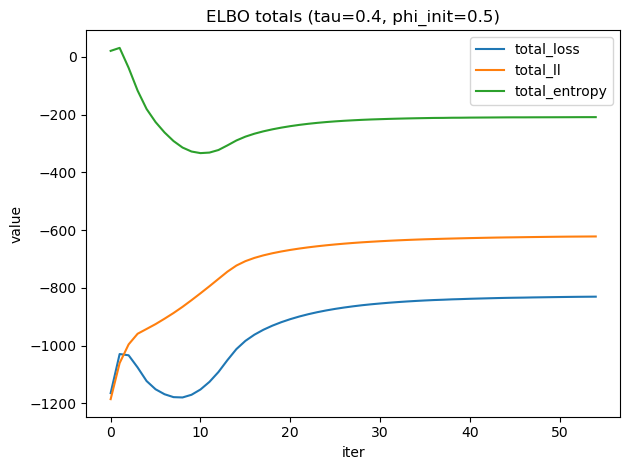

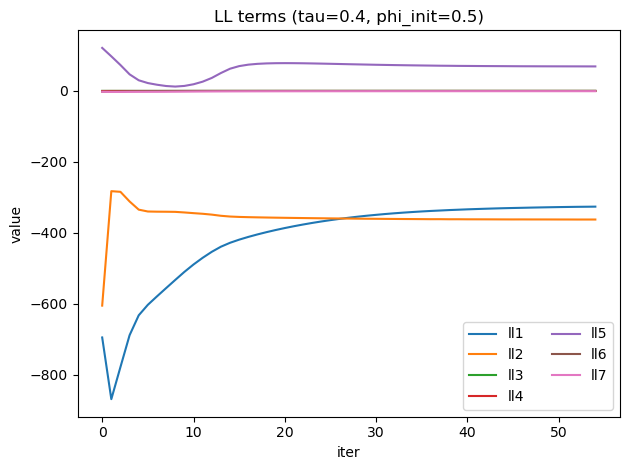

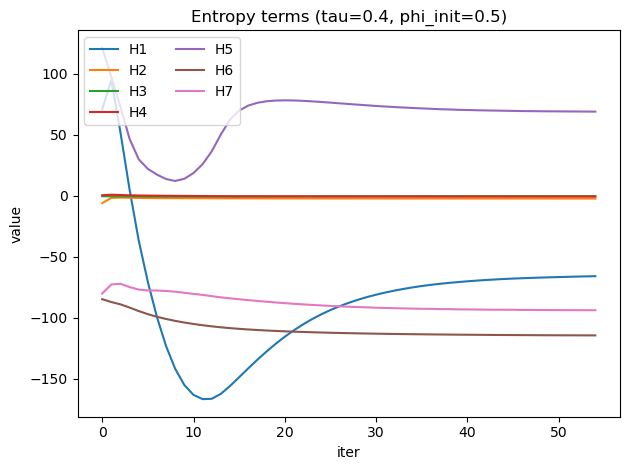

VI debug loop:  55%|█████▌    | 55/100 [3:46:59<3:02:04, 242.78s/it]


Iter 56/100 | mu_lambda_beta=7.9335 | sigmasq_lambda_beta=0.0102 | lambda_b1=1231.8672 | lambda_b2=888.2969
  E[phi]=1.4732 | ||mu_W||=44.0668 | min_eig_VX=7.936e-03 | min_eig_VS=2.319e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-829.8835 | total_ll=-621.3686 | total_entropy=-208.5150
  relative change in total_loss: 2.6609e-02


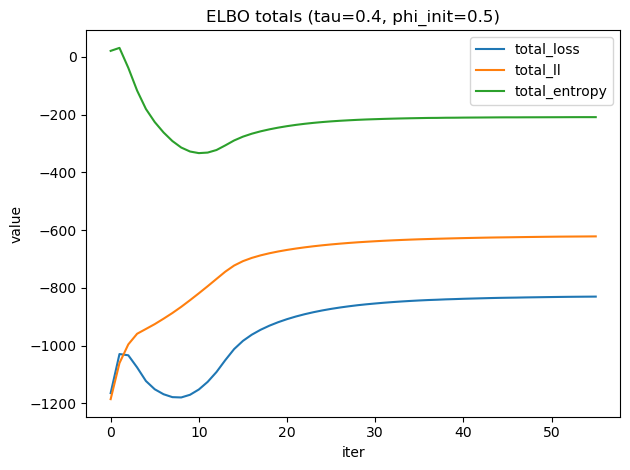

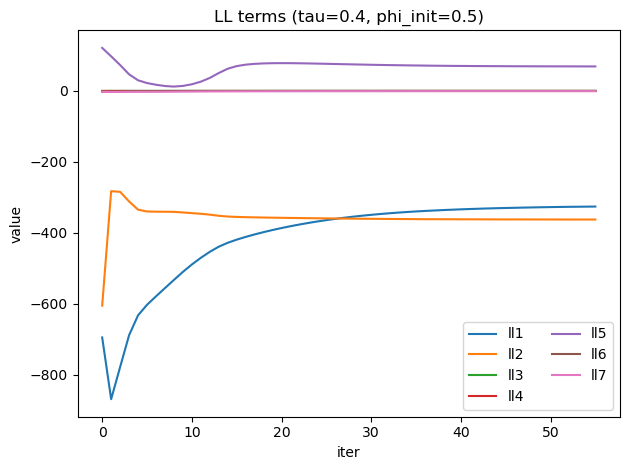

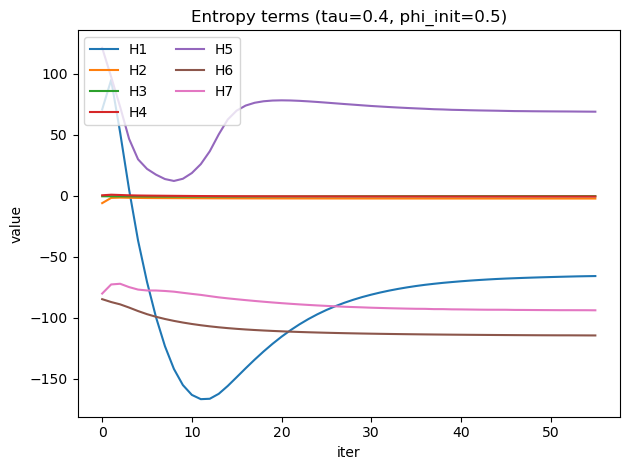

VI debug loop:  56%|█████▌    | 56/100 [3:47:18<2:08:52, 175.74s/it]


Iter 57/100 | mu_lambda_beta=7.9337 | sigmasq_lambda_beta=0.0102 | lambda_b1=1232.8835 | lambda_b2=887.5630
  E[phi]=1.4733 | ||mu_W||=44.0859 | min_eig_VX=7.923e-03 | min_eig_VS=2.312e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-829.5743 | total_ll=-621.1230 | total_entropy=-208.4513
  relative change in total_loss: 3.7259e-02


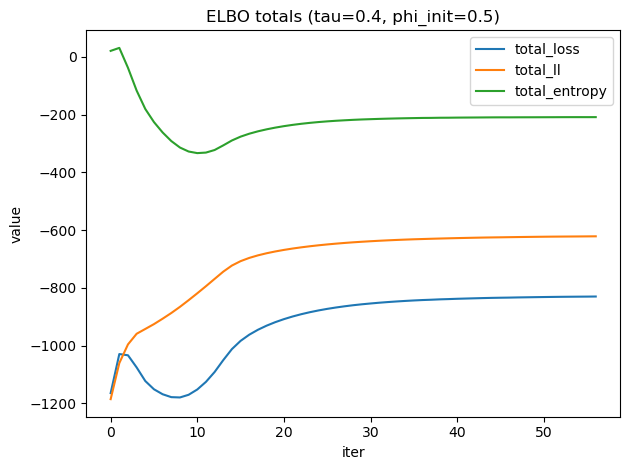

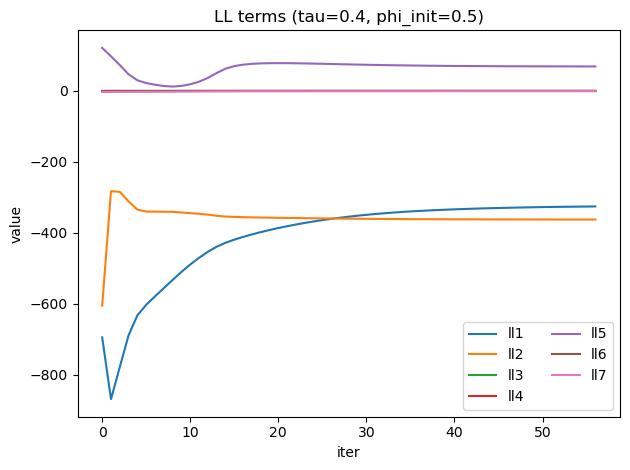

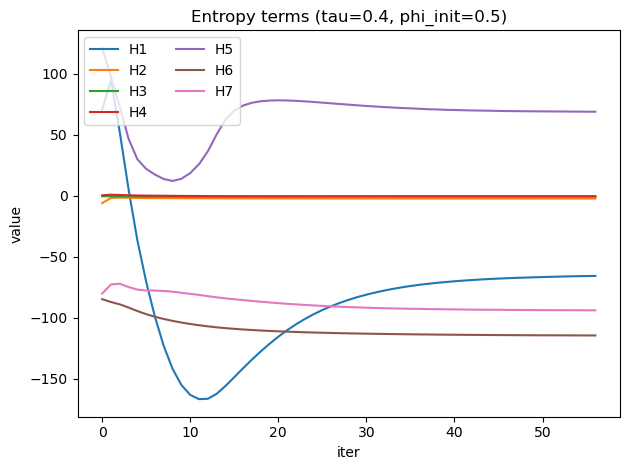

VI debug loop:  57%|█████▋    | 57/100 [3:47:30<1:30:42, 126.57s/it]


Iter 58/100 | mu_lambda_beta=7.9339 | sigmasq_lambda_beta=0.0102 | lambda_b1=1233.8613 | lambda_b2=886.9535
  E[phi]=1.4733 | ||mu_W||=44.1007 | min_eig_VX=7.913e-03 | min_eig_VS=2.309e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-829.3215 | total_ll=-620.9344 | total_entropy=-208.3872
  relative change in total_loss: 3.0474e-02


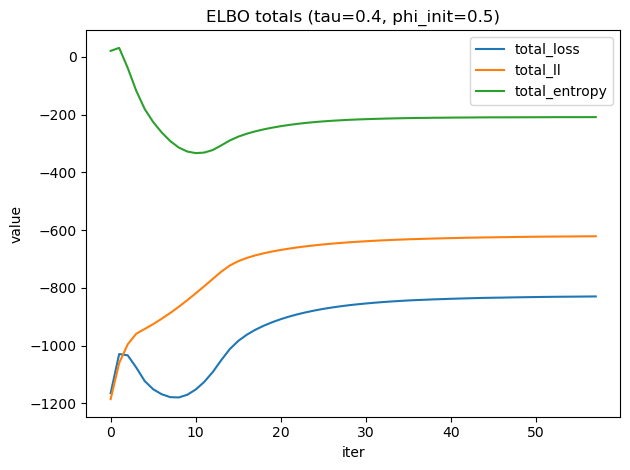

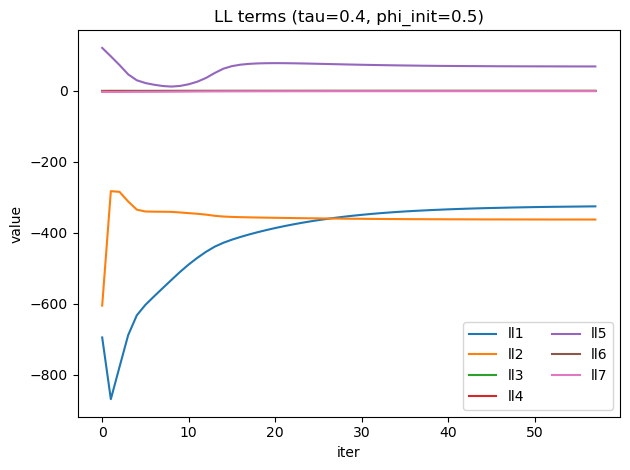

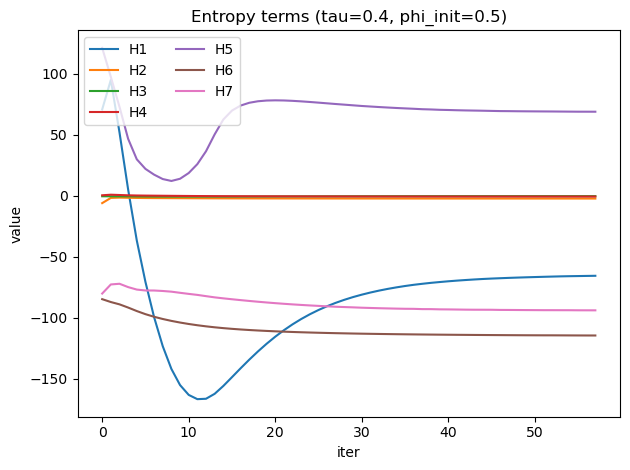

VI debug loop:  58%|█████▊    | 58/100 [3:47:40<1:03:59, 91.43s/it] 


Iter 59/100 | mu_lambda_beta=7.9340 | sigmasq_lambda_beta=0.0102 | lambda_b1=1234.7650 | lambda_b2=886.4530
  E[phi]=1.4733 | ||mu_W||=44.1131 | min_eig_VX=7.907e-03 | min_eig_VS=2.308e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-829.1284 | total_ll=-620.8019 | total_entropy=-208.3265
  relative change in total_loss: 2.3286e-02


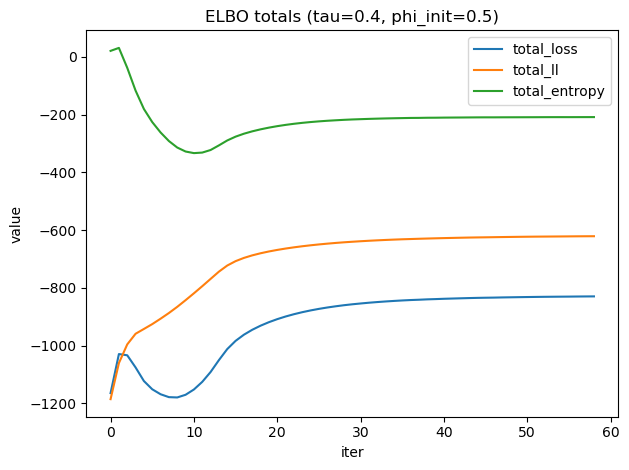

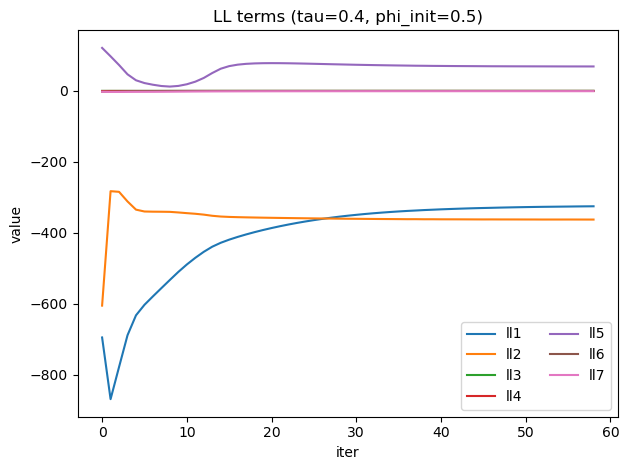

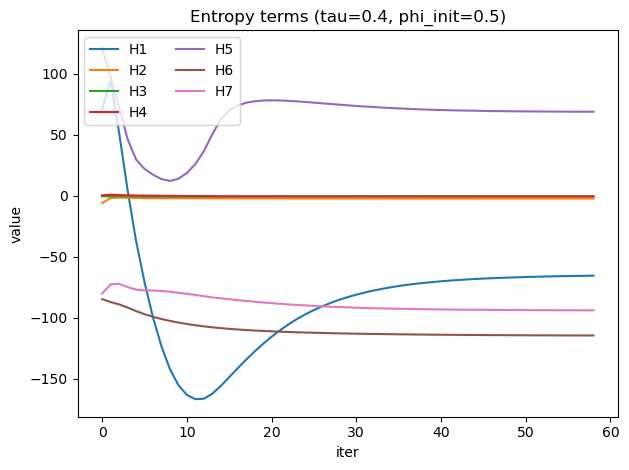

VI debug loop:  59%|█████▉    | 59/100 [3:47:45<44:45, 65.49s/it]  


Iter 60/100 | mu_lambda_beta=7.9340 | sigmasq_lambda_beta=0.0102 | lambda_b1=1235.5837 | lambda_b2=886.0711
  E[phi]=1.4733 | ||mu_W||=44.1242 | min_eig_VX=7.906e-03 | min_eig_VS=2.306e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.9579 | total_ll=-620.6857 | total_entropy=-208.2723
  relative change in total_loss: 2.0560e-02


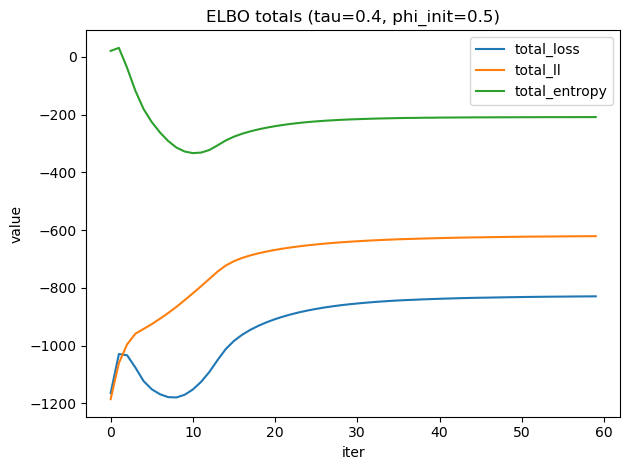

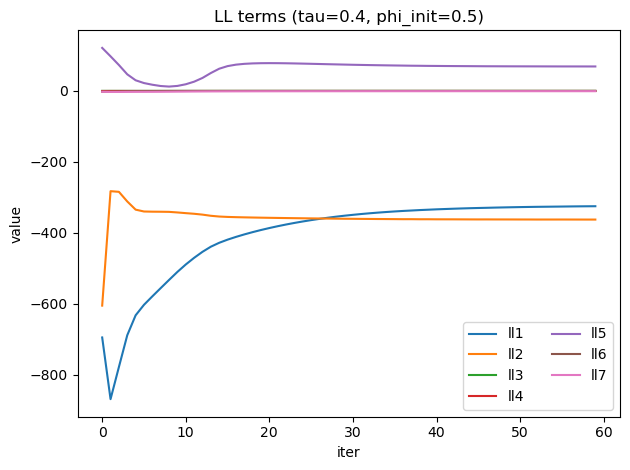

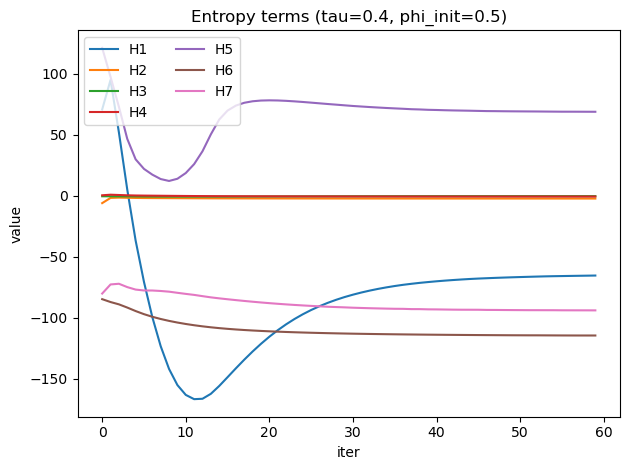

VI debug loop:  60%|██████    | 60/100 [3:47:51<31:49, 47.74s/it]


Iter 61/100 | mu_lambda_beta=7.9341 | sigmasq_lambda_beta=0.0102 | lambda_b1=1236.3253 | lambda_b2=885.7285
  E[phi]=1.4733 | ||mu_W||=44.1346 | min_eig_VX=7.904e-03 | min_eig_VS=2.303e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.7858 | total_ll=-620.5453 | total_entropy=-208.2405
  relative change in total_loss: 2.0763e-02


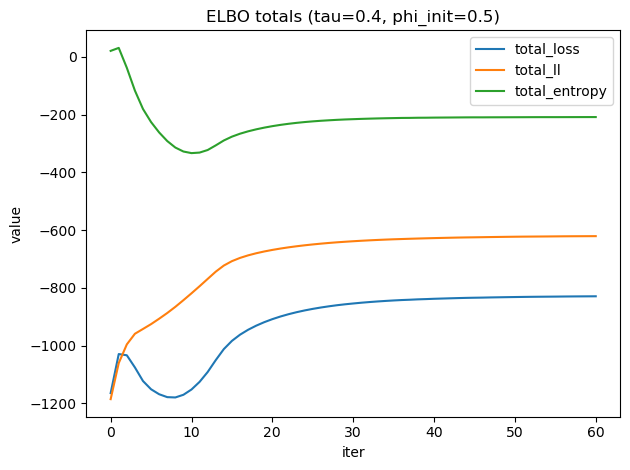

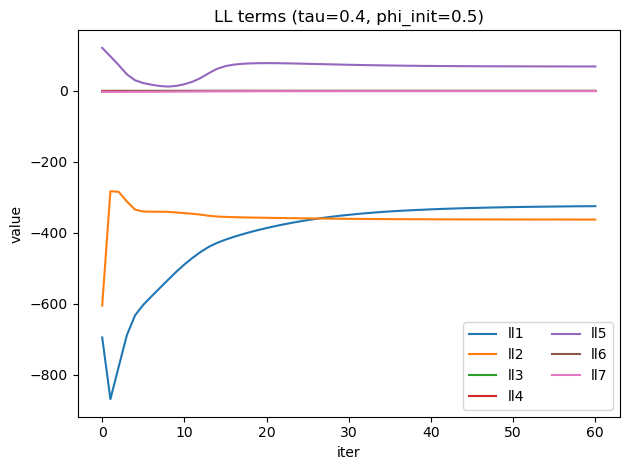

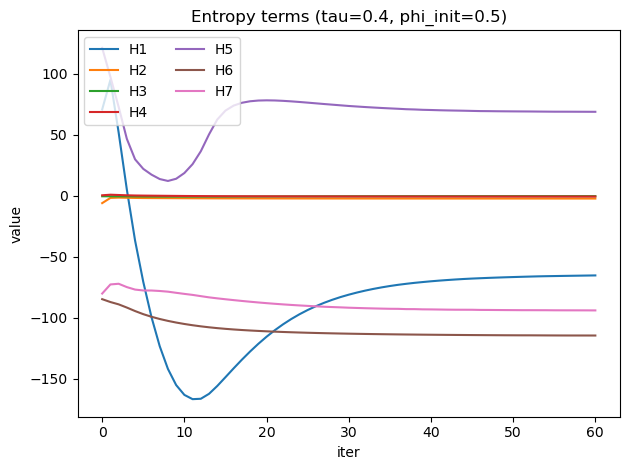

VI debug loop:  61%|██████    | 61/100 [3:48:02<23:53, 36.76s/it]


Iter 62/100 | mu_lambda_beta=7.9342 | sigmasq_lambda_beta=0.0102 | lambda_b1=1237.0010 | lambda_b2=885.3361
  E[phi]=1.4733 | ||mu_W||=44.1457 | min_eig_VX=7.898e-03 | min_eig_VS=2.300e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.6035 | total_ll=-620.4178 | total_entropy=-208.1857
  relative change in total_loss: 2.1997e-02


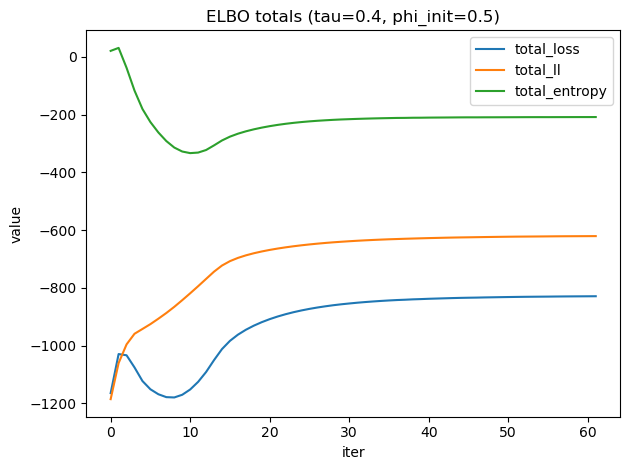

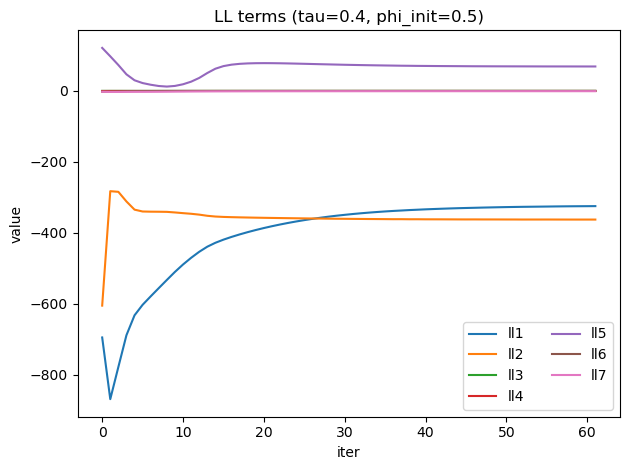

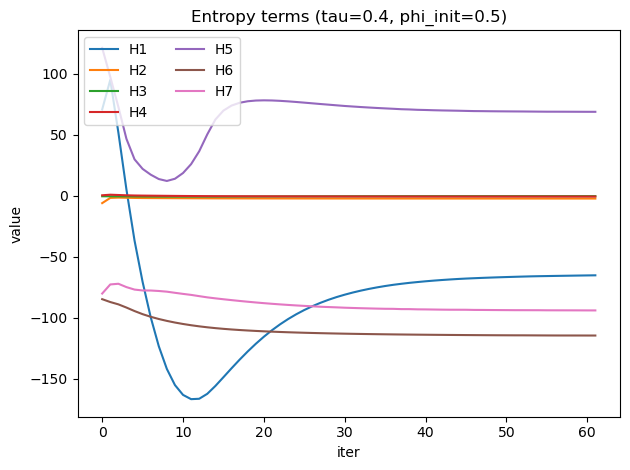

VI debug loop:  62%|██████▏   | 62/100 [3:48:10<17:47, 28.10s/it]


Iter 63/100 | mu_lambda_beta=7.9342 | sigmasq_lambda_beta=0.0102 | lambda_b1=1237.6378 | lambda_b2=885.0045
  E[phi]=1.4733 | ||mu_W||=44.1549 | min_eig_VX=7.894e-03 | min_eig_VS=2.298e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.4513 | total_ll=-620.3174 | total_entropy=-208.1339
  relative change in total_loss: 1.8371e-02


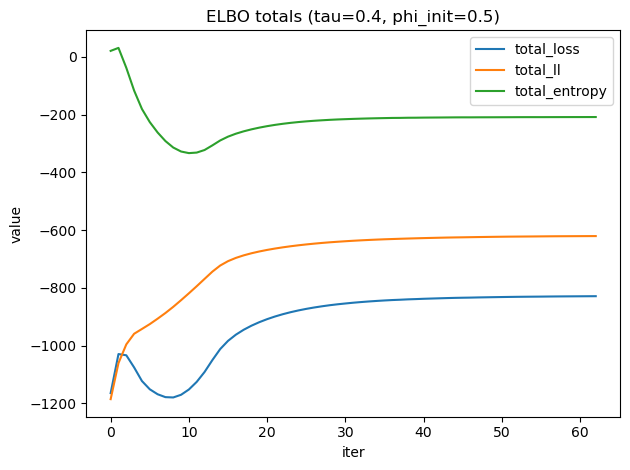

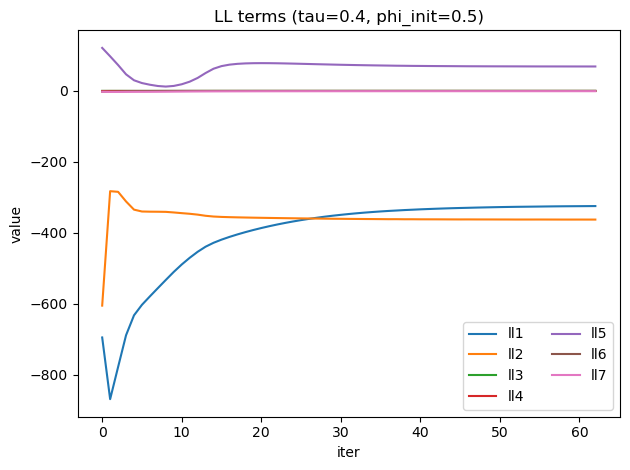

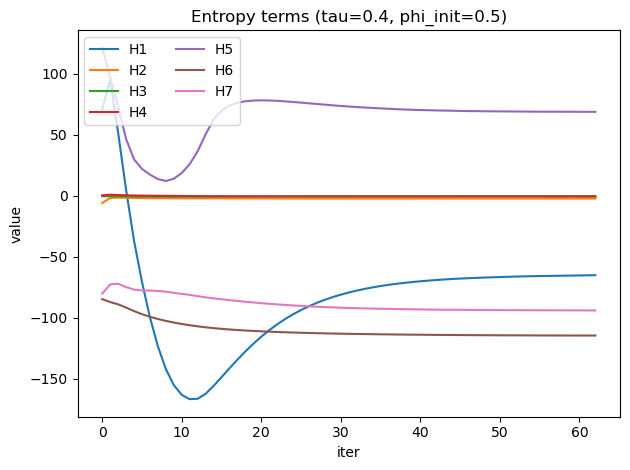

VI debug loop:  63%|██████▎   | 63/100 [3:48:17<13:21, 21.65s/it]


Iter 64/100 | mu_lambda_beta=7.9343 | sigmasq_lambda_beta=0.0102 | lambda_b1=1238.2218 | lambda_b2=884.7264
  E[phi]=1.4733 | ||mu_W||=44.1625 | min_eig_VX=7.890e-03 | min_eig_VS=2.297e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.3331 | total_ll=-620.2399 | total_entropy=-208.0932
  relative change in total_loss: 1.4263e-02


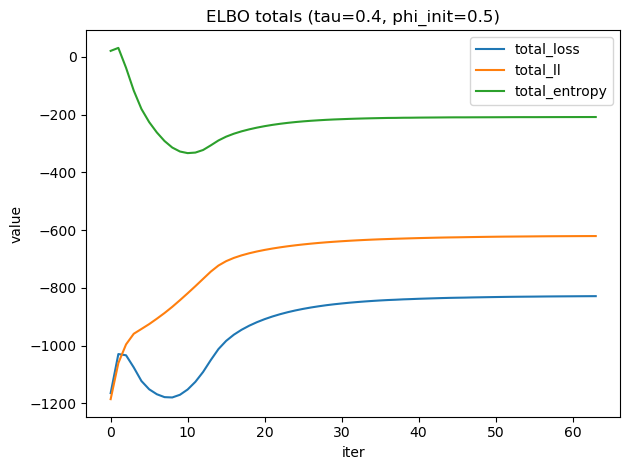

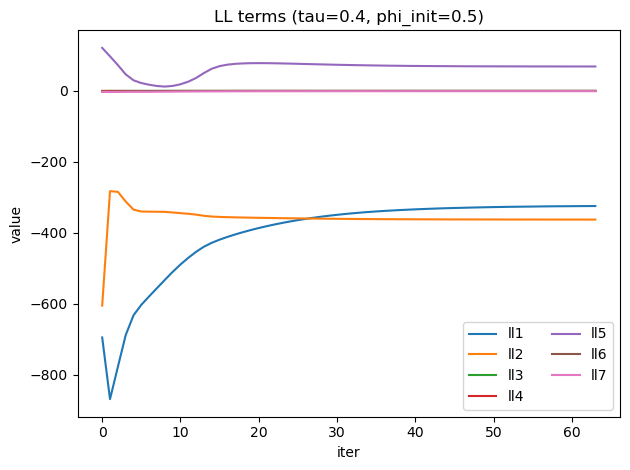

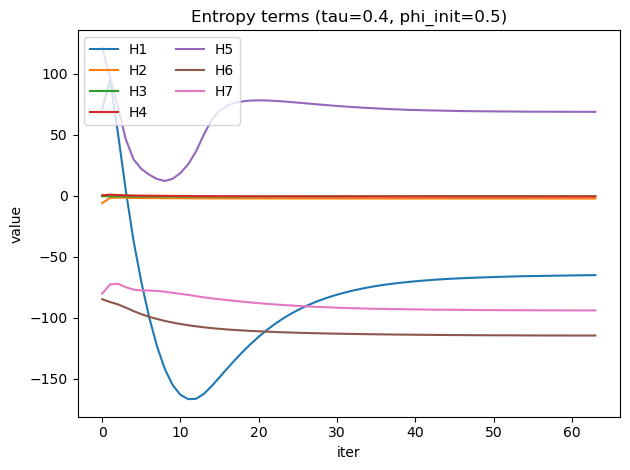

VI debug loop:  64%|██████▍   | 64/100 [3:48:23<10:13, 17.05s/it]


Iter 65/100 | mu_lambda_beta=7.9343 | sigmasq_lambda_beta=0.0102 | lambda_b1=1238.7476 | lambda_b2=884.4918
  E[phi]=1.4732 | ||mu_W||=44.1695 | min_eig_VX=7.889e-03 | min_eig_VS=2.296e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.2246 | total_ll=-620.1641 | total_entropy=-208.0605
  relative change in total_loss: 1.3101e-02


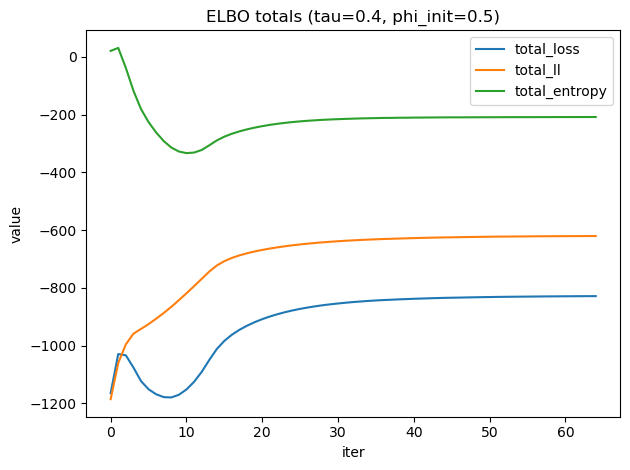

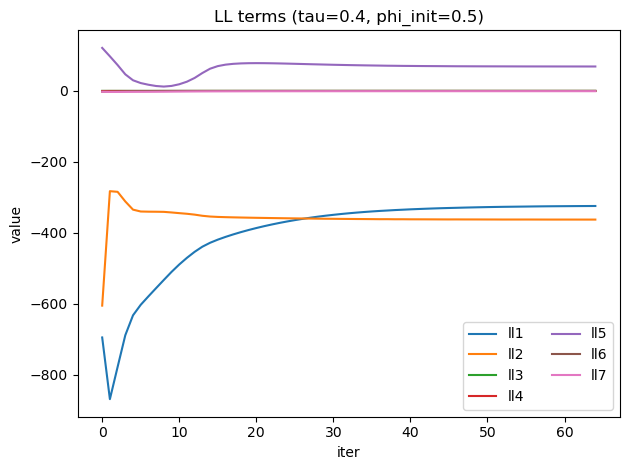

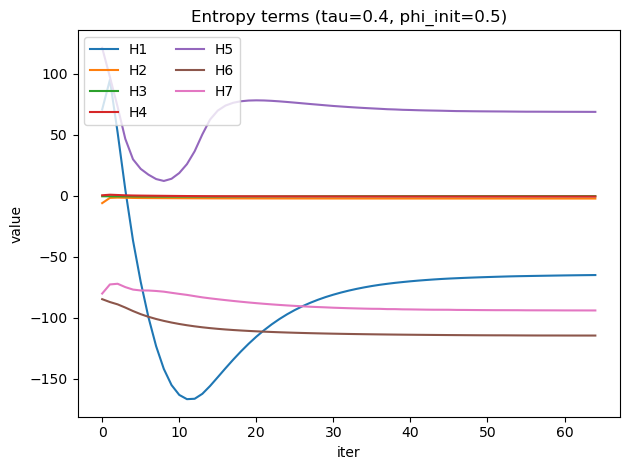

VI debug loop:  65%|██████▌   | 65/100 [3:48:31<08:26, 14.46s/it]


Iter 66/100 | mu_lambda_beta=7.9344 | sigmasq_lambda_beta=0.0102 | lambda_b1=1239.2222 | lambda_b2=884.2647
  E[phi]=1.4732 | ||mu_W||=44.1763 | min_eig_VX=7.886e-03 | min_eig_VS=2.294e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.1157 | total_ll=-620.0854 | total_entropy=-208.0302
  relative change in total_loss: 1.3154e-02


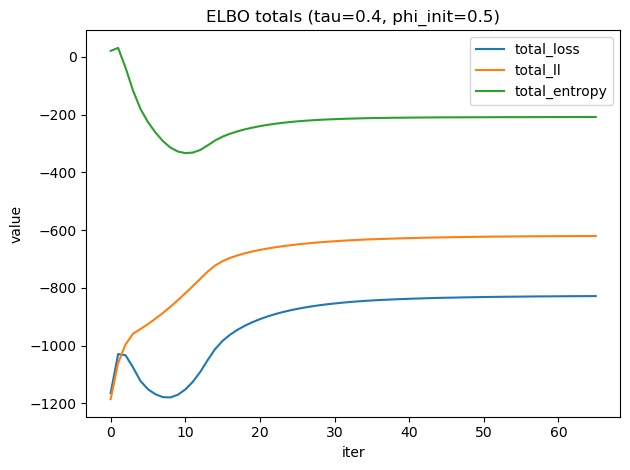

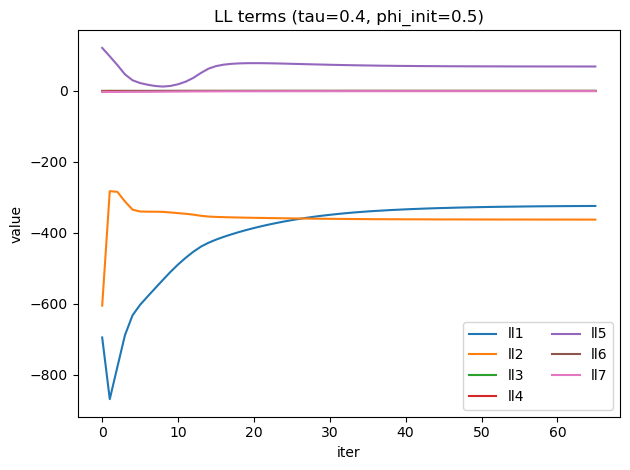

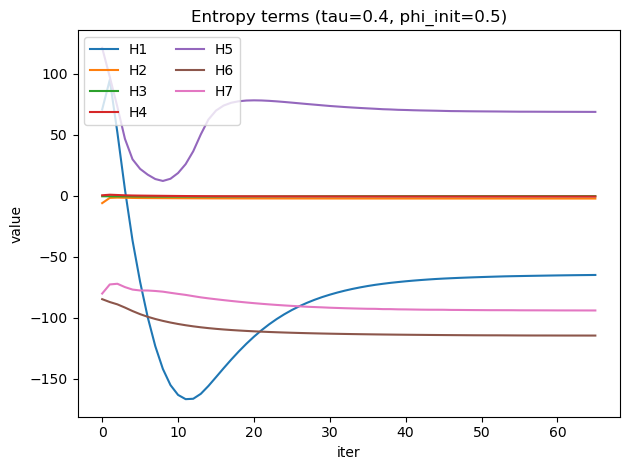

VI debug loop:  66%|██████▌   | 66/100 [3:48:40<07:08, 12.61s/it]


Iter 67/100 | mu_lambda_beta=7.9345 | sigmasq_lambda_beta=0.0102 | lambda_b1=1239.6566 | lambda_b2=884.0405
  E[phi]=1.4732 | ||mu_W||=44.1824 | min_eig_VX=7.882e-03 | min_eig_VS=2.293e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-828.0228 | total_ll=-620.0168 | total_entropy=-208.0060
  relative change in total_loss: 1.1210e-02


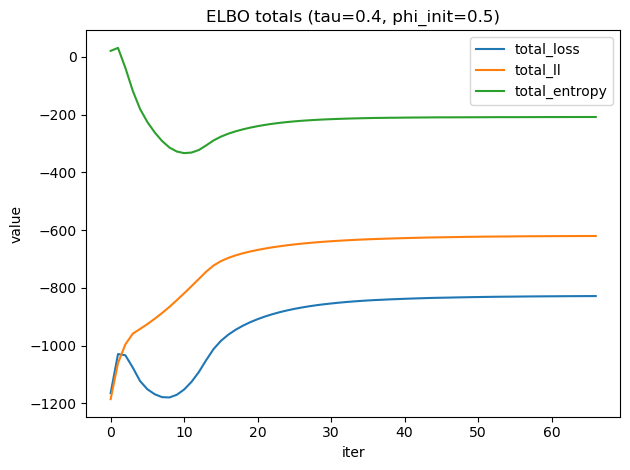

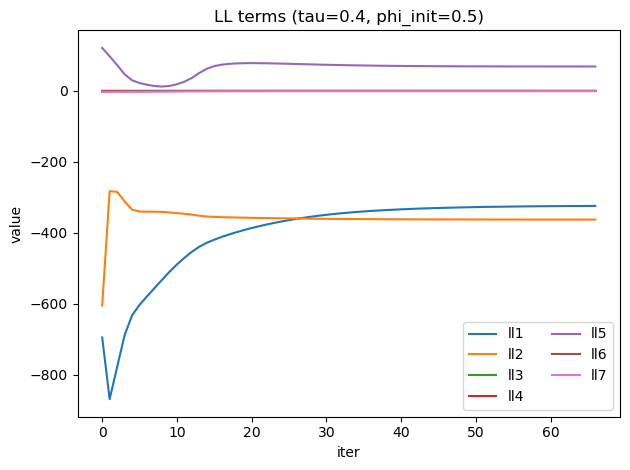

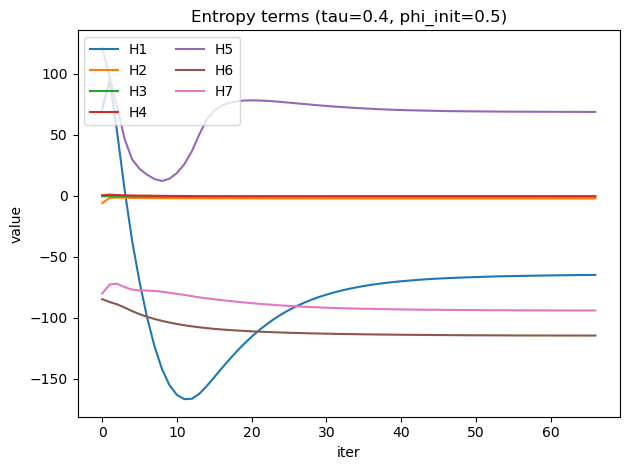

VI debug loop:  67%|██████▋   | 67/100 [3:48:46<05:54, 10.75s/it]


Iter 68/100 | mu_lambda_beta=7.9345 | sigmasq_lambda_beta=0.0102 | lambda_b1=1240.0530 | lambda_b2=883.8445
  E[phi]=1.4732 | ||mu_W||=44.1888 | min_eig_VX=7.881e-03 | min_eig_VS=2.291e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.9114 | total_ll=-619.9504 | total_entropy=-207.9610
  relative change in total_loss: 1.3460e-02


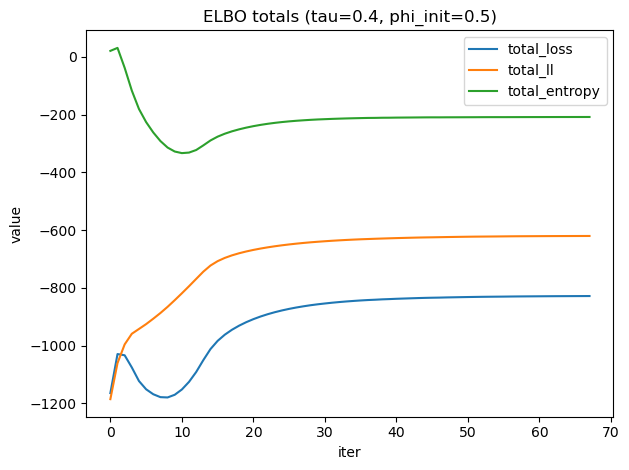

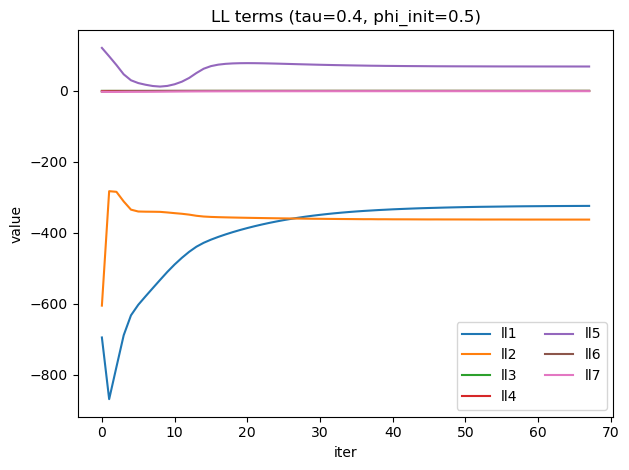

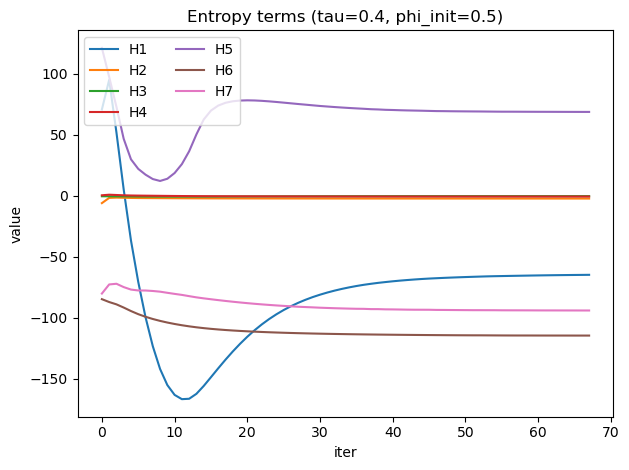

VI debug loop:  68%|██████▊   | 68/100 [3:48:53<05:07,  9.62s/it]


Iter 69/100 | mu_lambda_beta=7.9345 | sigmasq_lambda_beta=0.0102 | lambda_b1=1240.4291 | lambda_b2=883.6757
  E[phi]=1.4732 | ||mu_W||=44.1942 | min_eig_VX=7.880e-03 | min_eig_VS=2.290e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.8127 | total_ll=-619.8926 | total_entropy=-207.9201
  relative change in total_loss: 1.1913e-02


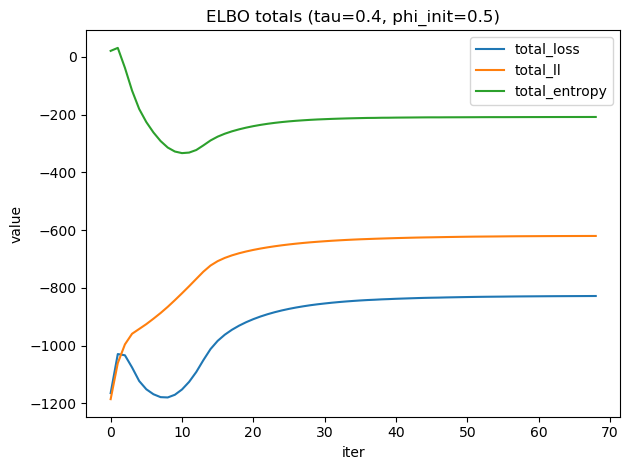

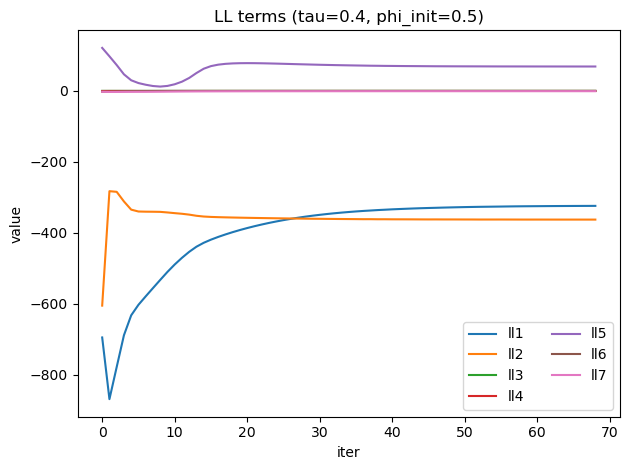

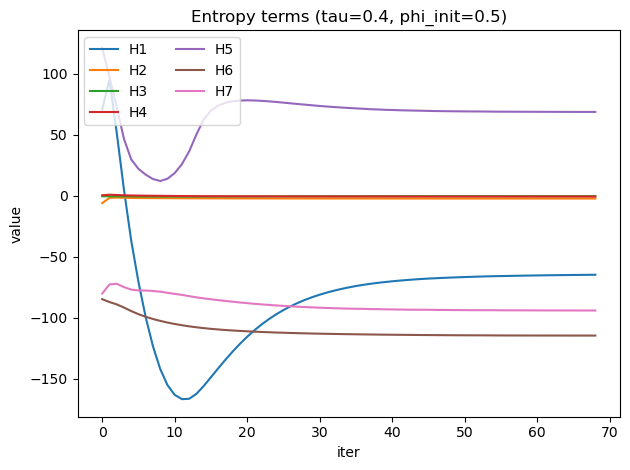

VI debug loop:  69%|██████▉   | 69/100 [3:48:59<04:27,  8.64s/it]


Iter 70/100 | mu_lambda_beta=7.9345 | sigmasq_lambda_beta=0.0102 | lambda_b1=1240.7780 | lambda_b2=883.5212
  E[phi]=1.4733 | ||mu_W||=44.1991 | min_eig_VX=7.877e-03 | min_eig_VS=2.289e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.7128 | total_ll=-619.8109 | total_entropy=-207.9018
  relative change in total_loss: 1.2077e-02


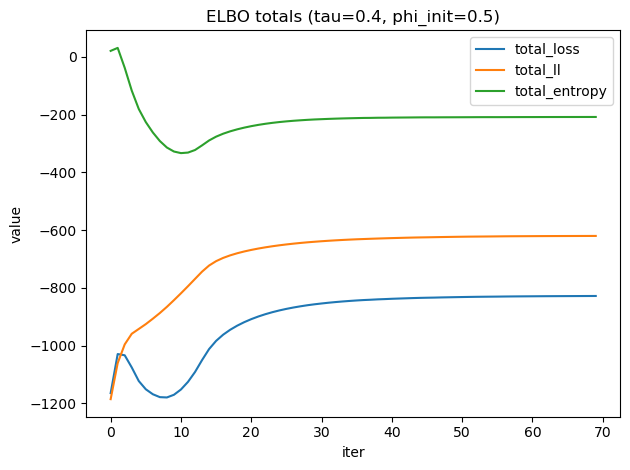

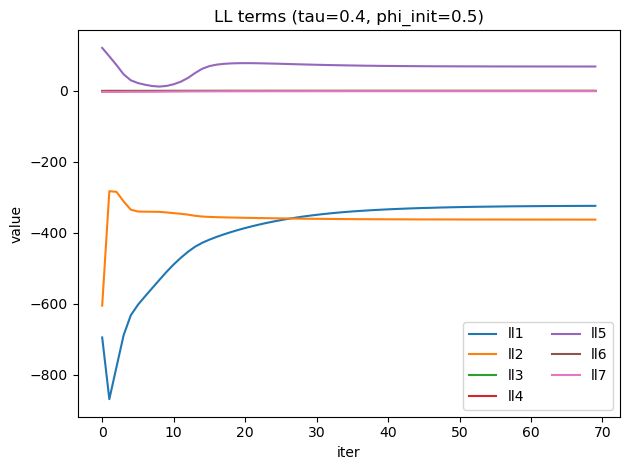

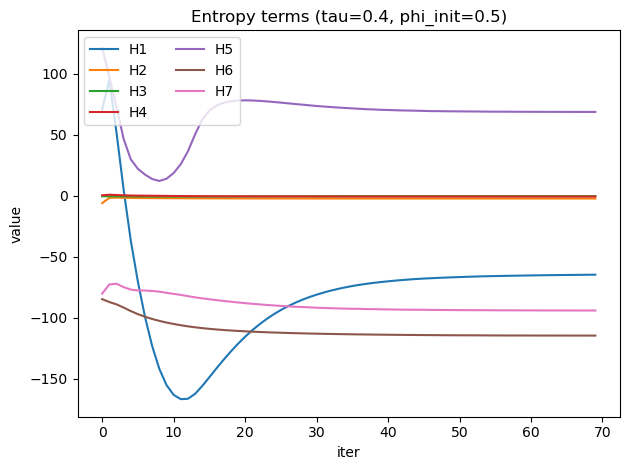

VI debug loop:  70%|███████   | 70/100 [3:49:12<04:50,  9.70s/it]


Iter 71/100 | mu_lambda_beta=7.9347 | sigmasq_lambda_beta=0.0102 | lambda_b1=1241.0988 | lambda_b2=883.3043
  E[phi]=1.4733 | ||mu_W||=44.2040 | min_eig_VX=7.869e-03 | min_eig_VS=2.288e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.6349 | total_ll=-619.7542 | total_entropy=-207.8807
  relative change in total_loss: 9.4018e-03


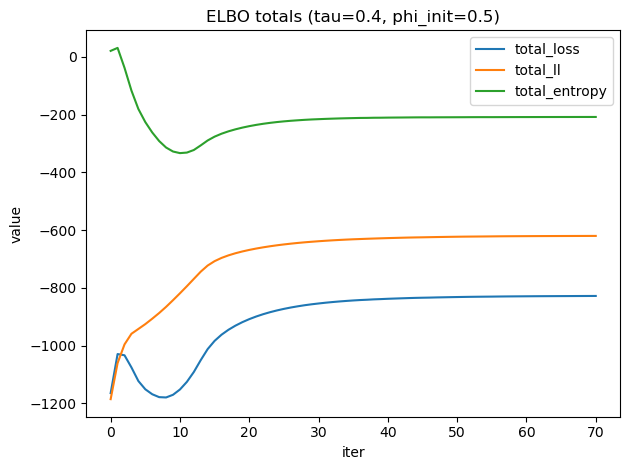

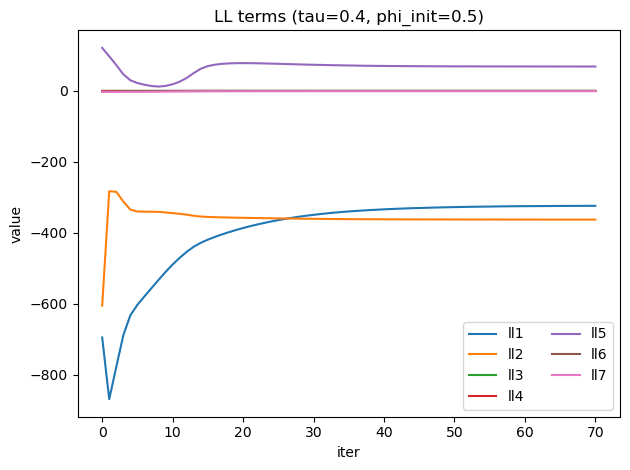

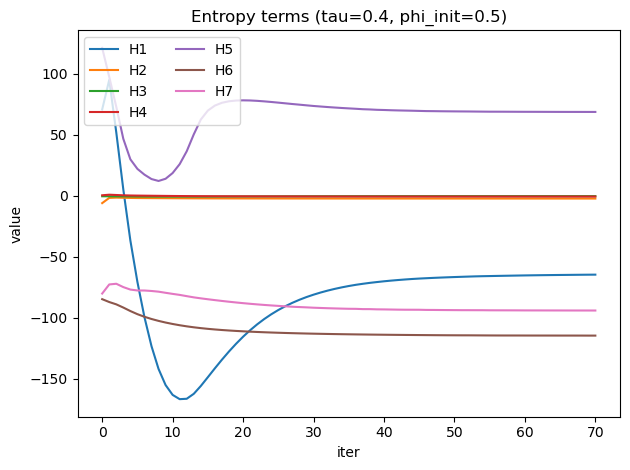

VI debug loop:  71%|███████   | 71/100 [3:49:17<04:05,  8.46s/it]


Iter 72/100 | mu_lambda_beta=7.9348 | sigmasq_lambda_beta=0.0102 | lambda_b1=1241.3947 | lambda_b2=883.1519
  E[phi]=1.4733 | ||mu_W||=44.2083 | min_eig_VX=7.869e-03 | min_eig_VS=2.288e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.5511 | total_ll=-619.6978 | total_entropy=-207.8533
  relative change in total_loss: 1.0133e-02


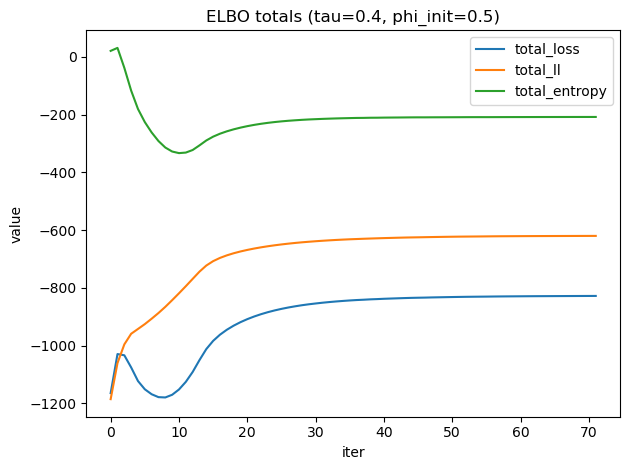

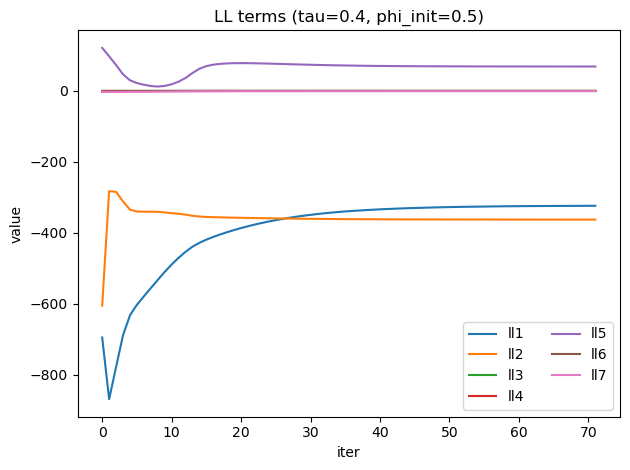

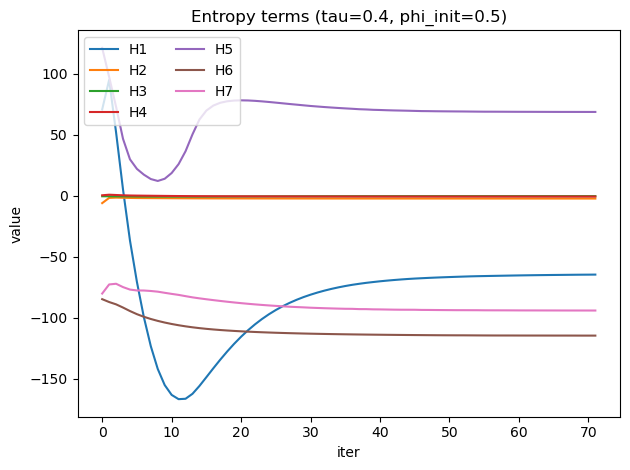

VI debug loop:  72%|███████▏  | 72/100 [3:49:25<03:50,  8.22s/it]


Iter 73/100 | mu_lambda_beta=7.9348 | sigmasq_lambda_beta=0.0102 | lambda_b1=1241.6715 | lambda_b2=883.0075
  E[phi]=1.4733 | ||mu_W||=44.2125 | min_eig_VX=7.866e-03 | min_eig_VS=2.287e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.4727 | total_ll=-619.6542 | total_entropy=-207.8185
  relative change in total_loss: 9.4700e-03


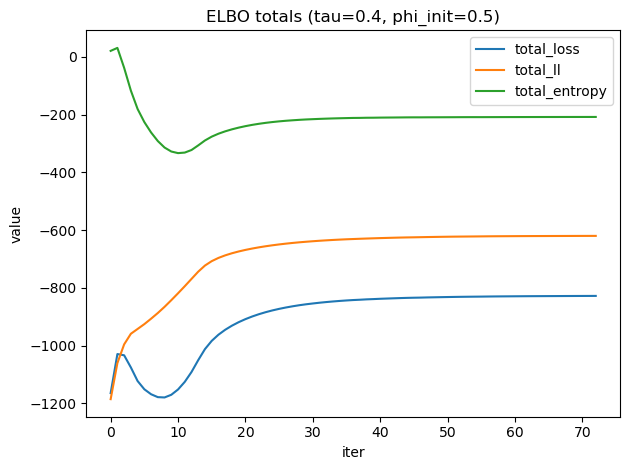

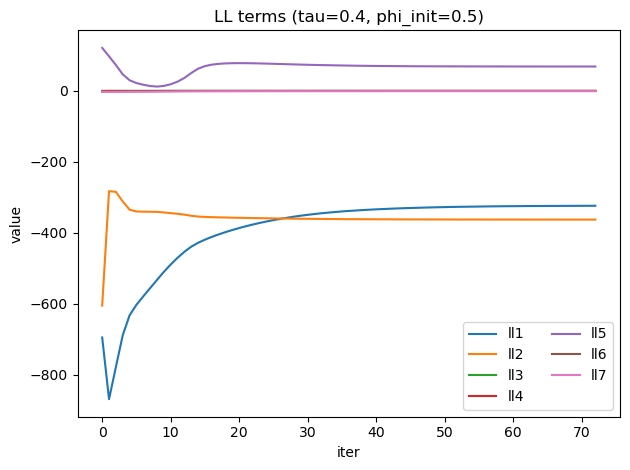

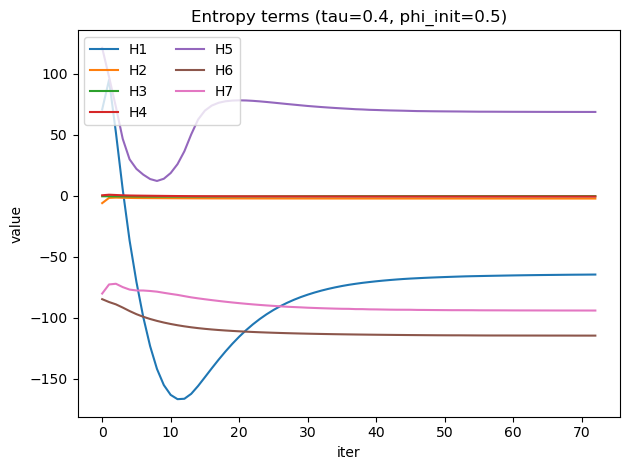

VI debug loop:  73%|███████▎  | 73/100 [3:49:30<03:20,  7.44s/it]


Iter 74/100 | mu_lambda_beta=7.9349 | sigmasq_lambda_beta=0.0102 | lambda_b1=1241.9323 | lambda_b2=882.8983
  E[phi]=1.4733 | ||mu_W||=44.2161 | min_eig_VX=7.866e-03 | min_eig_VS=2.286e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.4033 | total_ll=-619.6155 | total_entropy=-207.7878
  relative change in total_loss: 8.3866e-03


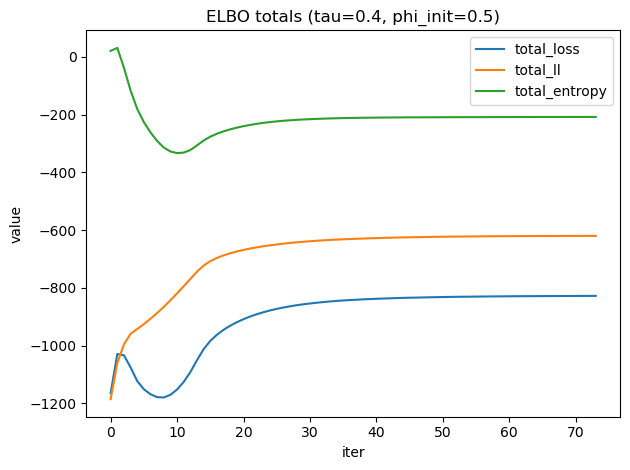

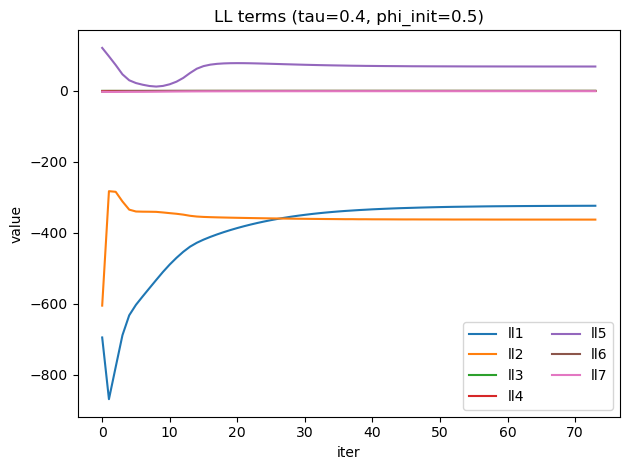

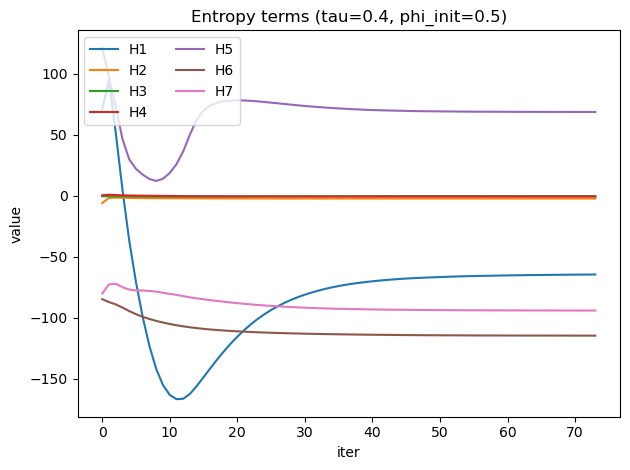

VI debug loop:  74%|███████▍  | 74/100 [3:49:36<03:01,  6.98s/it]


Iter 75/100 | mu_lambda_beta=7.9349 | sigmasq_lambda_beta=0.0102 | lambda_b1=1242.1738 | lambda_b2=882.7957
  E[phi]=1.4733 | ||mu_W||=44.2191 | min_eig_VX=7.864e-03 | min_eig_VS=2.286e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.3420 | total_ll=-619.5662 | total_entropy=-207.7758
  relative change in total_loss: 7.4136e-03


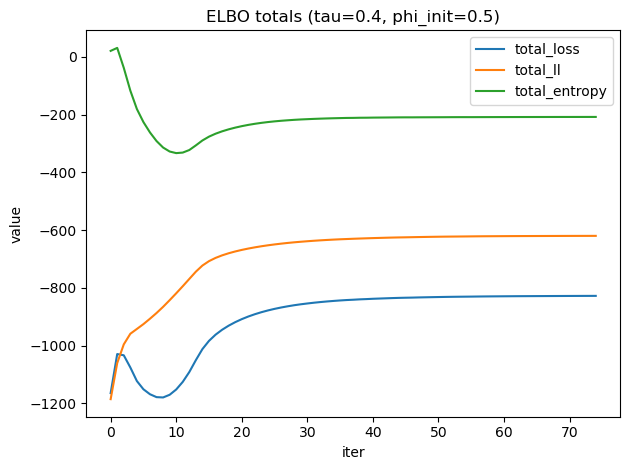

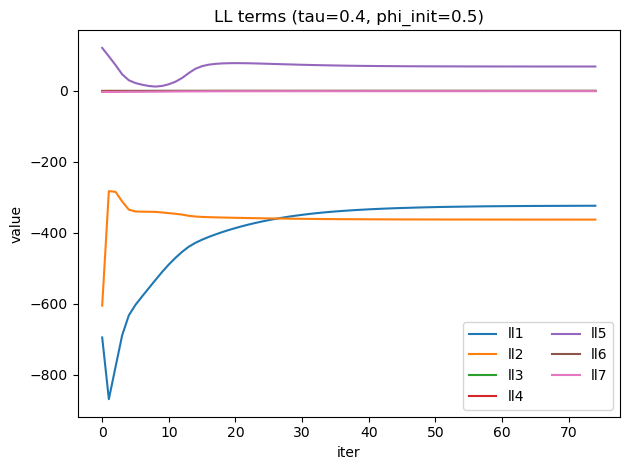

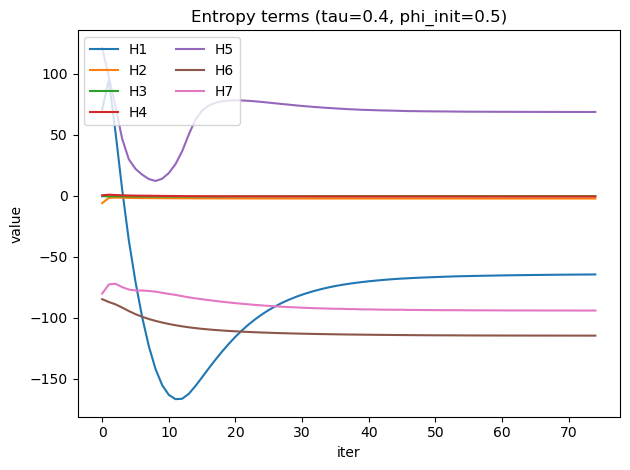

VI debug loop:  75%|███████▌  | 75/100 [3:49:46<03:13,  7.73s/it]


Iter 76/100 | mu_lambda_beta=7.9351 | sigmasq_lambda_beta=0.0102 | lambda_b1=1242.3918 | lambda_b2=882.6597
  E[phi]=1.4733 | ||mu_W||=44.2226 | min_eig_VX=7.860e-03 | min_eig_VS=2.285e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.2816 | total_ll=-619.5300 | total_entropy=-207.7516
  relative change in total_loss: 7.2961e-03


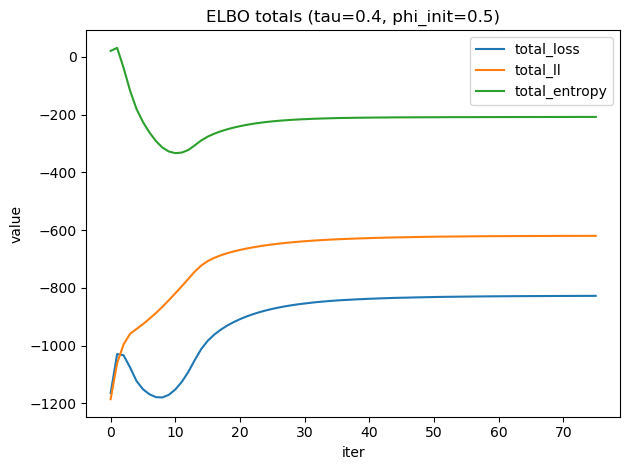

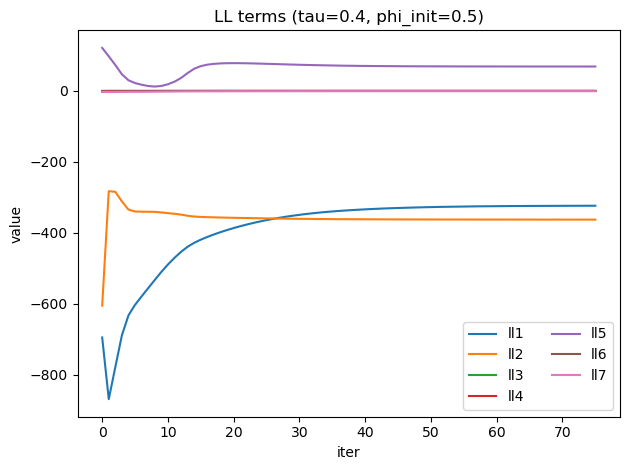

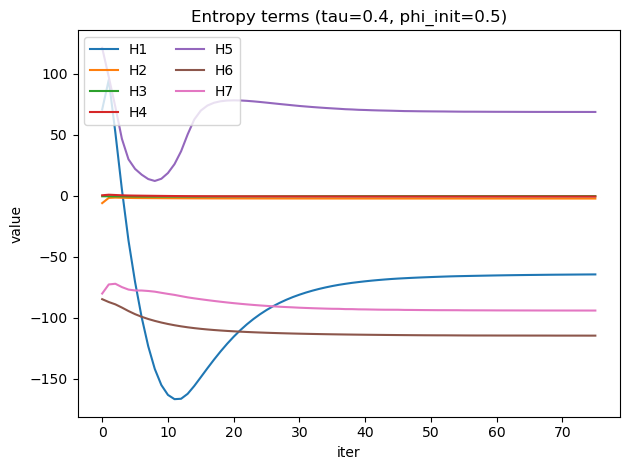

VI debug loop:  76%|███████▌  | 76/100 [3:49:50<02:42,  6.77s/it]


Iter 77/100 | mu_lambda_beta=7.9351 | sigmasq_lambda_beta=0.0102 | lambda_b1=1242.5981 | lambda_b2=882.5676
  E[phi]=1.4733 | ||mu_W||=44.2251 | min_eig_VX=7.859e-03 | min_eig_VS=2.285e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.2266 | total_ll=-619.4838 | total_entropy=-207.7429
  relative change in total_loss: 6.6474e-03


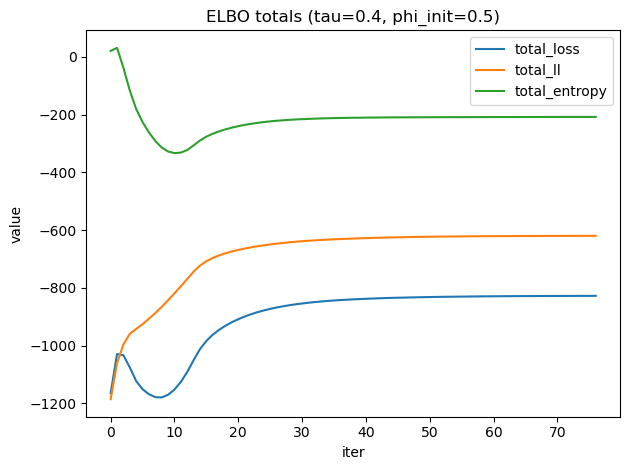

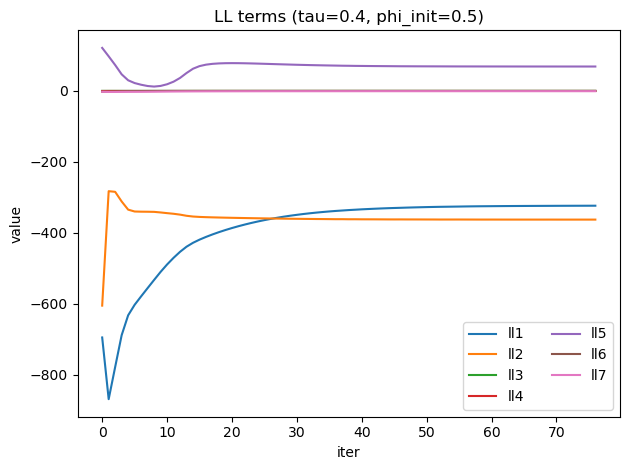

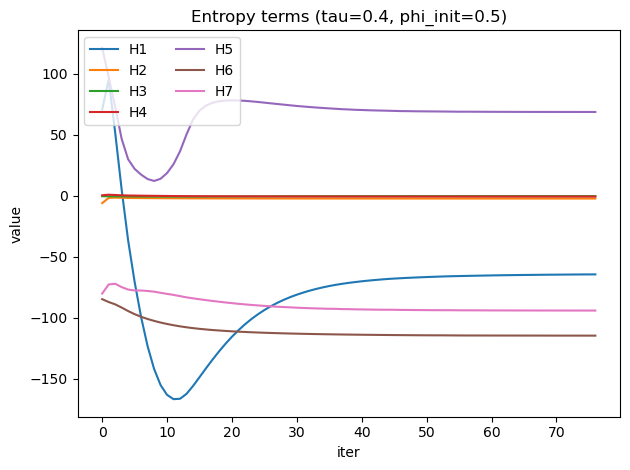

VI debug loop:  77%|███████▋  | 77/100 [3:49:59<02:48,  7.34s/it]


Iter 78/100 | mu_lambda_beta=7.9353 | sigmasq_lambda_beta=0.0102 | lambda_b1=1242.7838 | lambda_b2=882.4415
  E[phi]=1.4733 | ||mu_W||=44.2278 | min_eig_VX=7.855e-03 | min_eig_VS=2.284e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.1783 | total_ll=-619.4457 | total_entropy=-207.7326
  relative change in total_loss: 5.8362e-03


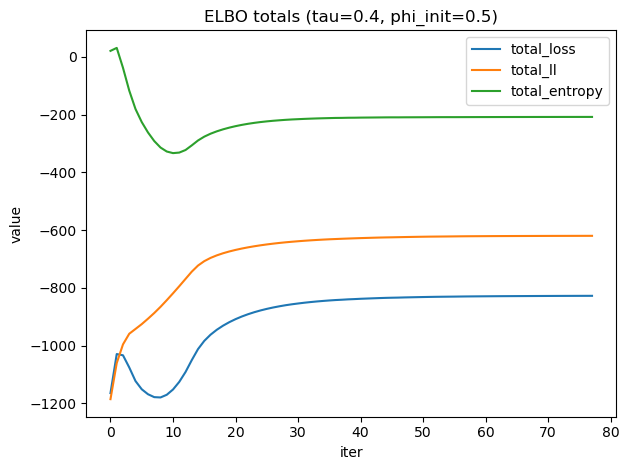

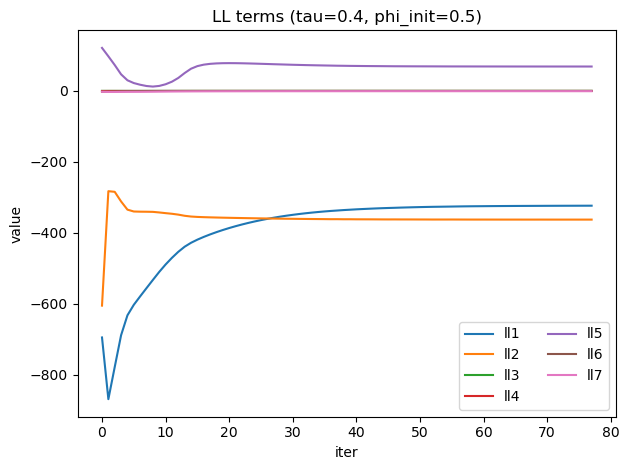

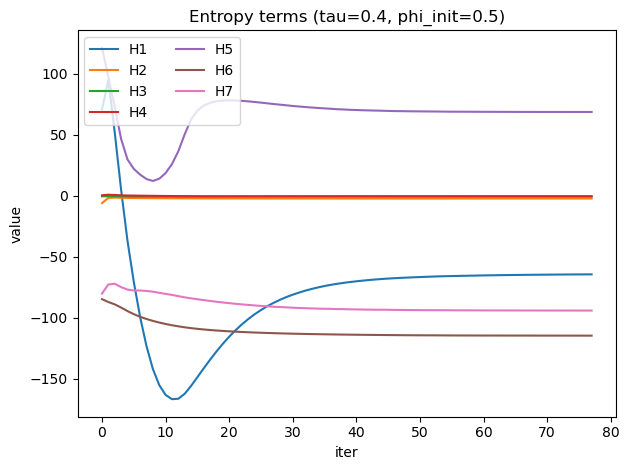

VI debug loop:  78%|███████▊  | 78/100 [3:50:05<02:29,  6.80s/it]


Iter 79/100 | mu_lambda_beta=7.9354 | sigmasq_lambda_beta=0.0102 | lambda_b1=1242.9546 | lambda_b2=882.3408
  E[phi]=1.4733 | ||mu_W||=44.2301 | min_eig_VX=7.853e-03 | min_eig_VS=2.284e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.1392 | total_ll=-619.4193 | total_entropy=-207.7200
  relative change in total_loss: 4.7298e-03


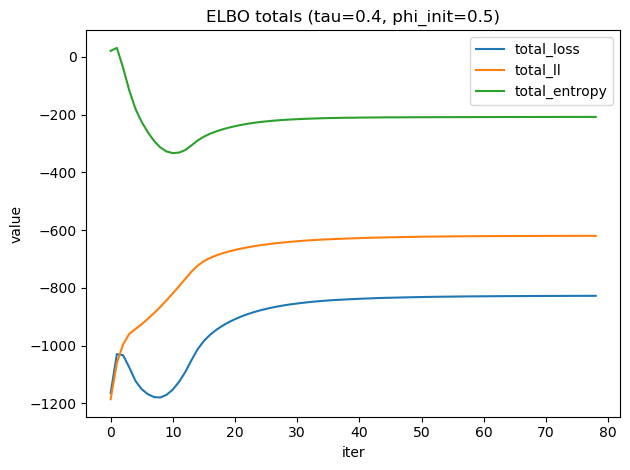

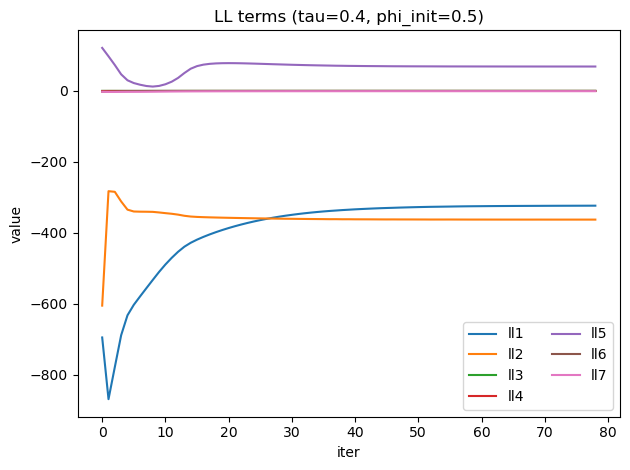

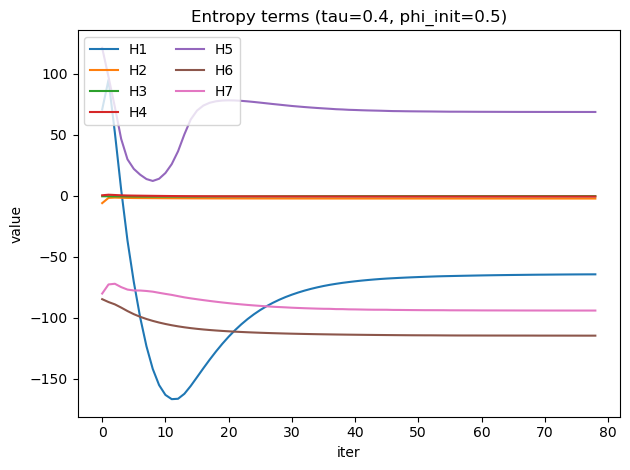

VI debug loop:  79%|███████▉  | 79/100 [3:50:09<02:07,  6.08s/it]


Iter 80/100 | mu_lambda_beta=7.9354 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.1102 | lambda_b2=882.2675
  E[phi]=1.4733 | ||mu_W||=44.2321 | min_eig_VX=7.853e-03 | min_eig_VS=2.284e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.0946 | total_ll=-619.3763 | total_entropy=-207.7183
  relative change in total_loss: 5.3941e-03


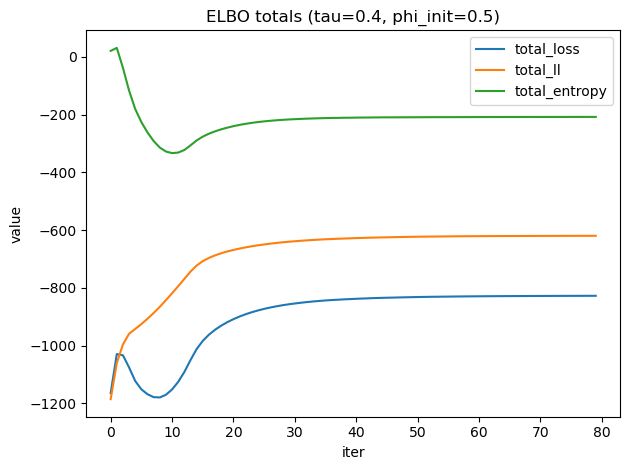

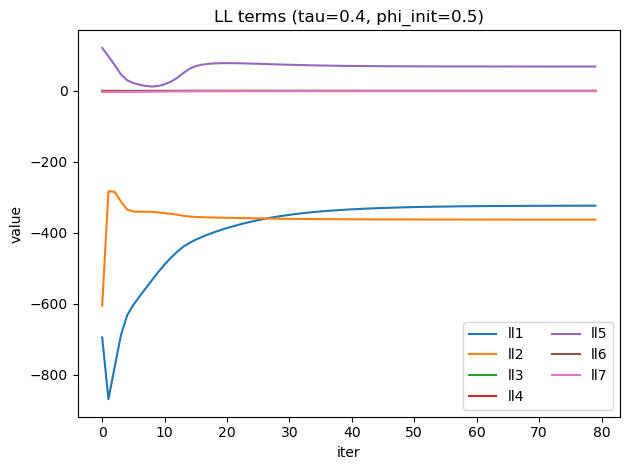

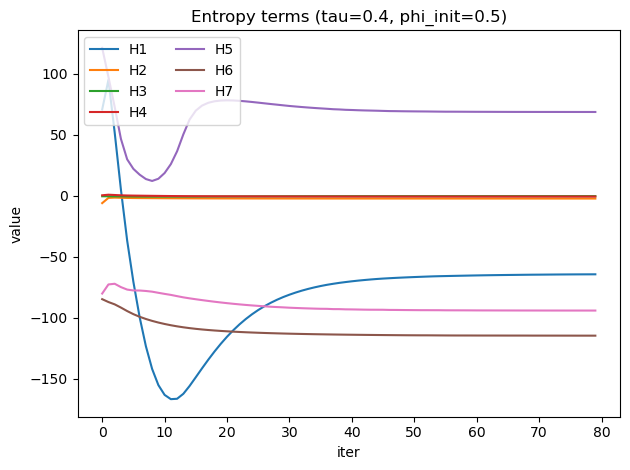

VI debug loop:  80%|████████  | 80/100 [3:50:18<02:20,  7.04s/it]


Iter 81/100 | mu_lambda_beta=7.9356 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.2513 | lambda_b2=882.1543
  E[phi]=1.4733 | ||mu_W||=44.2345 | min_eig_VX=7.848e-03 | min_eig_VS=2.283e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.0482 | total_ll=-619.3416 | total_entropy=-207.7067
  relative change in total_loss: 5.6084e-03


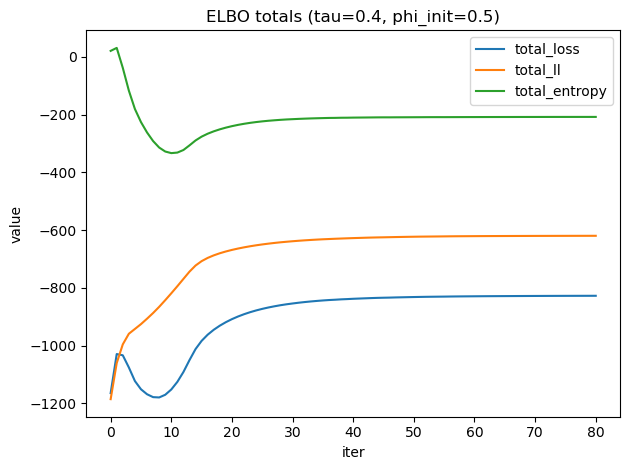

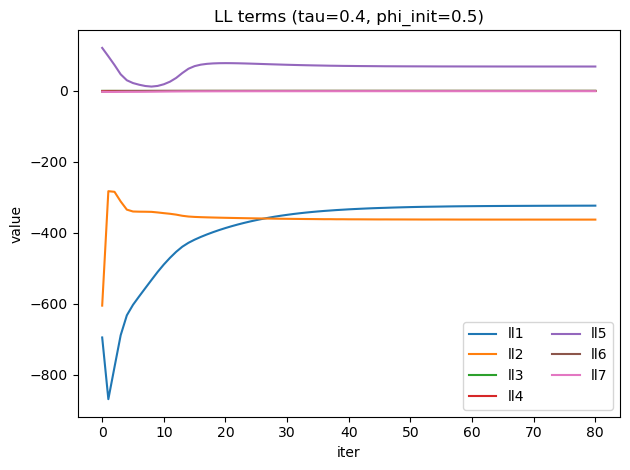

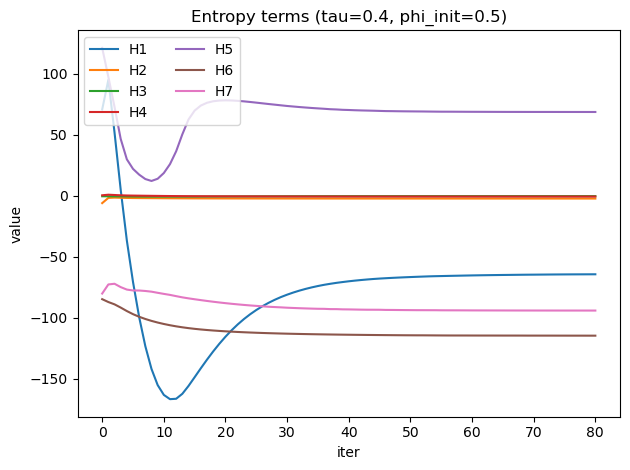

VI debug loop:  81%|████████  | 81/100 [3:50:24<02:06,  6.65s/it]


Iter 82/100 | mu_lambda_beta=7.9357 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.3872 | lambda_b2=882.0715
  E[phi]=1.4733 | ||mu_W||=44.2364 | min_eig_VX=7.847e-03 | min_eig_VS=2.283e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-827.0067 | total_ll=-619.3073 | total_entropy=-207.6993
  relative change in total_loss: 5.0257e-03


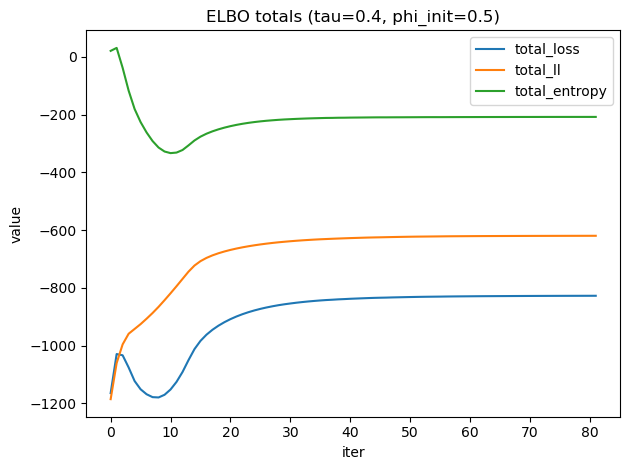

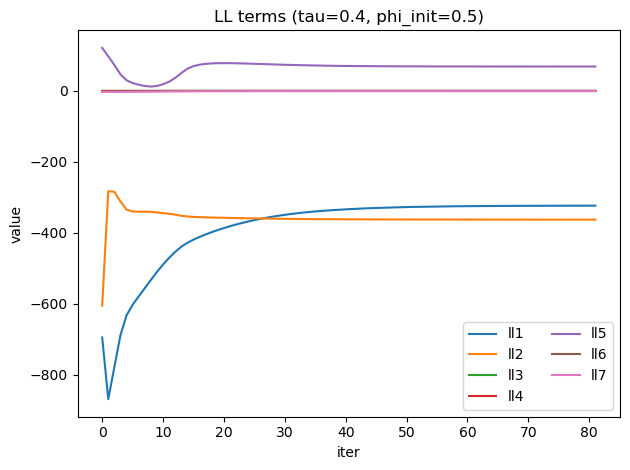

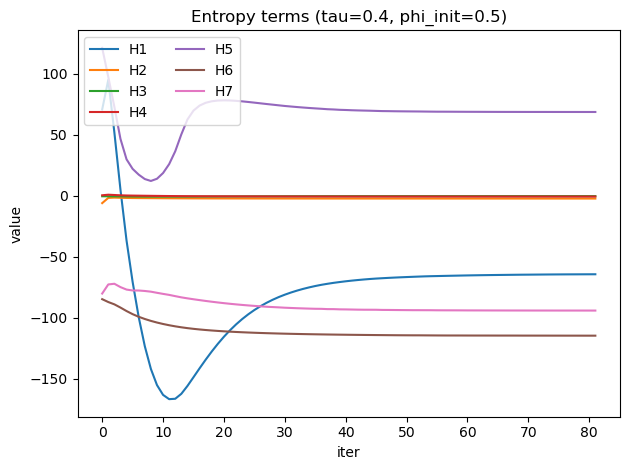

VI debug loop:  82%|████████▏ | 82/100 [3:50:30<01:58,  6.57s/it]


Iter 83/100 | mu_lambda_beta=7.9358 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.5139 | lambda_b2=881.9872
  E[phi]=1.4734 | ||mu_W||=44.2387 | min_eig_VX=7.846e-03 | min_eig_VS=2.282e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.9545 | total_ll=-619.2715 | total_entropy=-207.6830
  relative change in total_loss: 6.3101e-03


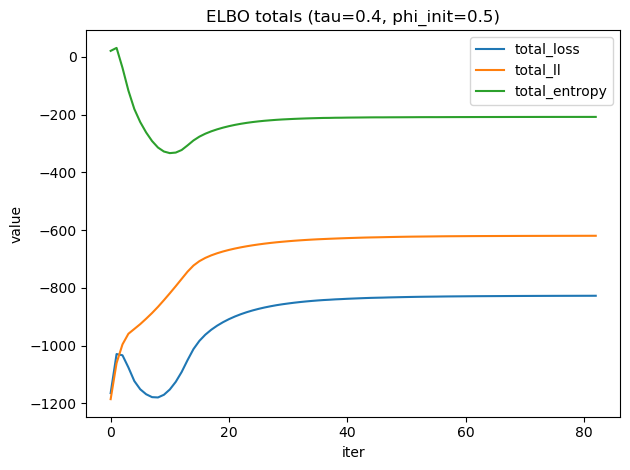

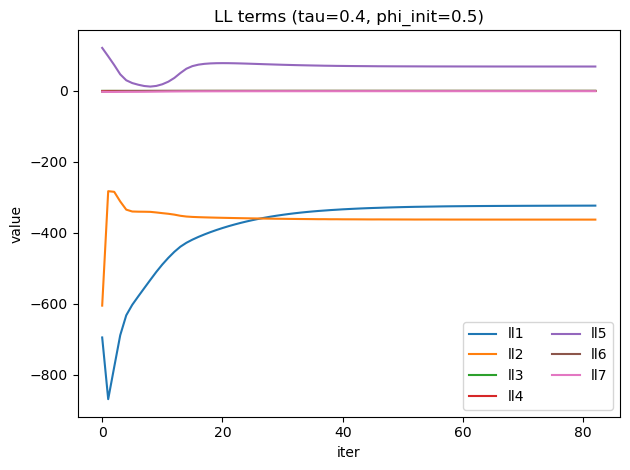

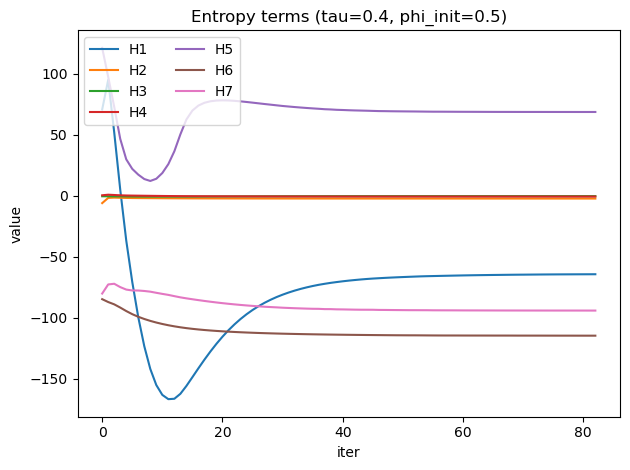

VI debug loop:  83%|████████▎ | 83/100 [3:50:37<01:51,  6.54s/it]


Iter 84/100 | mu_lambda_beta=7.9359 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.6401 | lambda_b2=881.9100
  E[phi]=1.4734 | ||mu_W||=44.2409 | min_eig_VX=7.845e-03 | min_eig_VS=2.281e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.9019 | total_ll=-619.2399 | total_entropy=-207.6620
  relative change in total_loss: 6.3548e-03


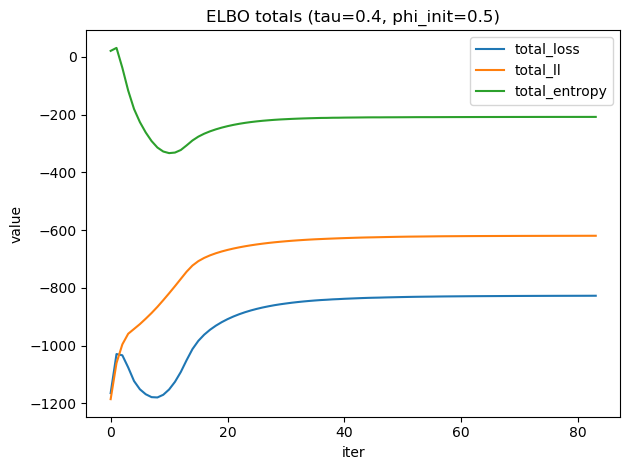

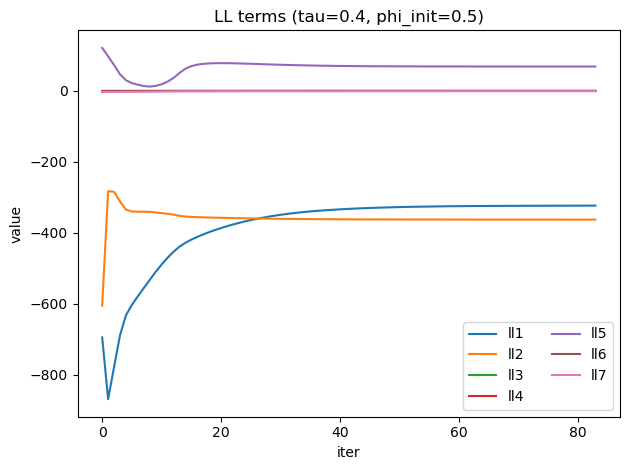

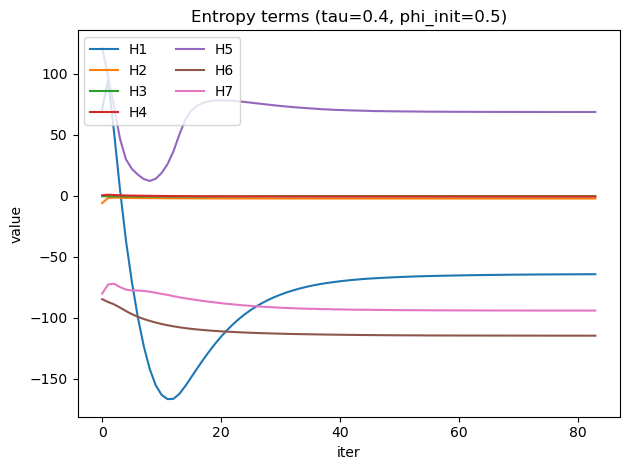

VI debug loop:  84%|████████▍ | 84/100 [3:50:43<01:42,  6.39s/it]


Iter 85/100 | mu_lambda_beta=7.9359 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.7659 | lambda_b2=881.8446
  E[phi]=1.4734 | ||mu_W||=44.2431 | min_eig_VX=7.844e-03 | min_eig_VS=2.281e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.8480 | total_ll=-619.2126 | total_entropy=-207.6354
  relative change in total_loss: 6.5176e-03


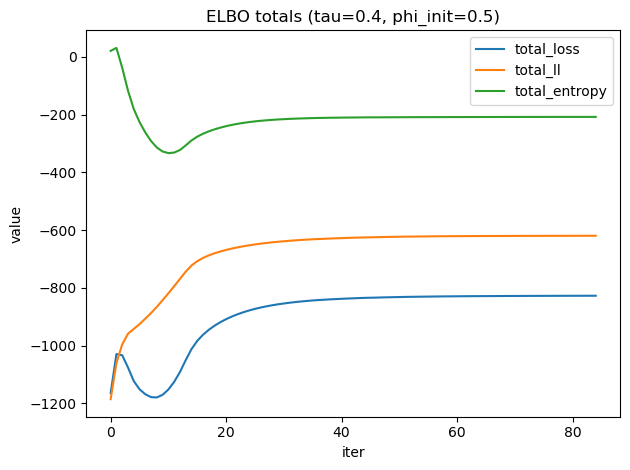

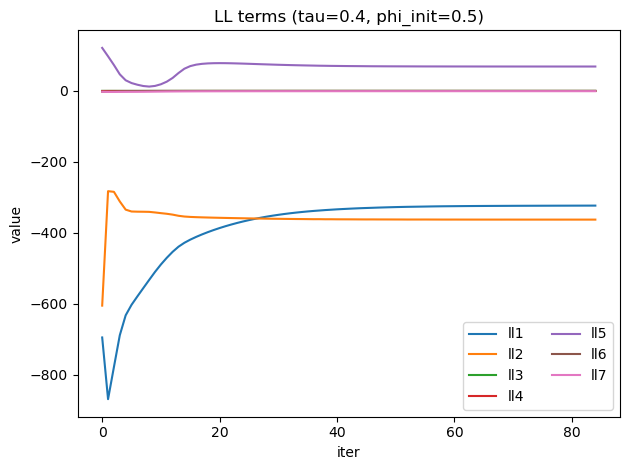

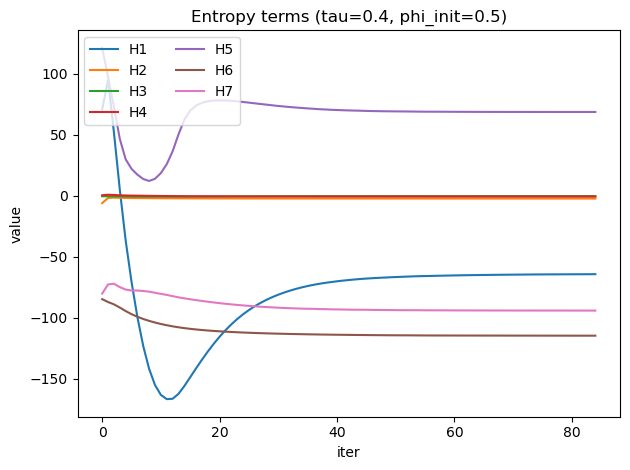

VI debug loop:  85%|████████▌ | 85/100 [3:50:49<01:33,  6.20s/it]


Iter 86/100 | mu_lambda_beta=7.9360 | sigmasq_lambda_beta=0.0102 | lambda_b1=1243.8917 | lambda_b2=881.7904
  E[phi]=1.4734 | ||mu_W||=44.2449 | min_eig_VX=7.843e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.8048 | total_ll=-619.1921 | total_entropy=-207.6127
  relative change in total_loss: 5.2262e-03


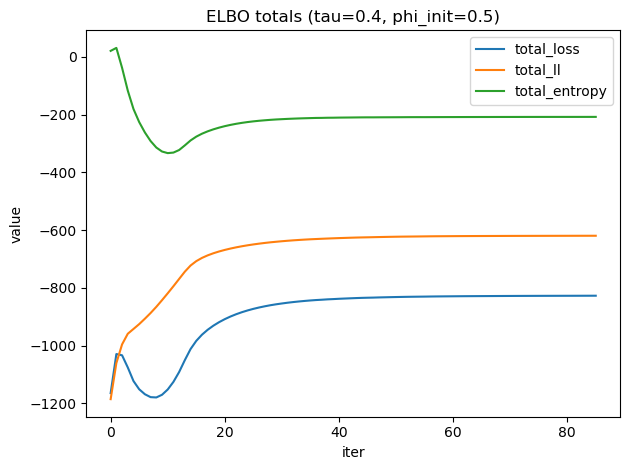

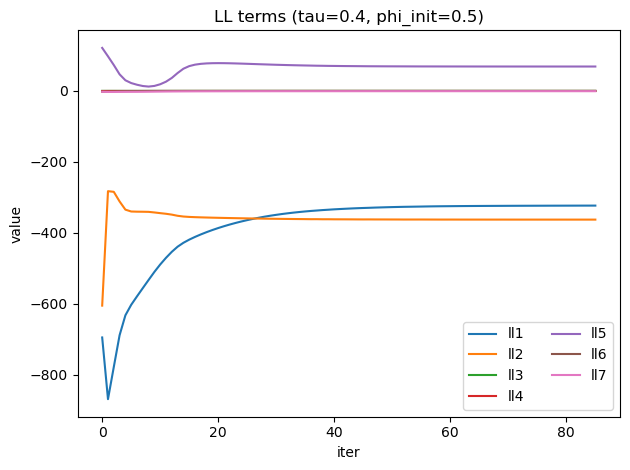

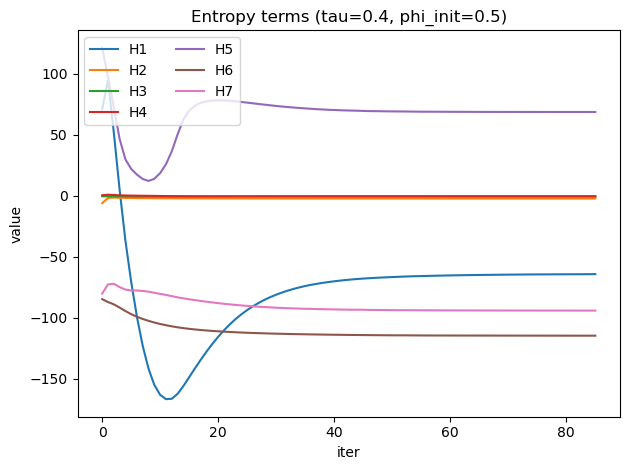

VI debug loop:  86%|████████▌ | 86/100 [3:50:54<01:21,  5.83s/it]


Iter 87/100 | mu_lambda_beta=7.9360 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.0116 | lambda_b2=881.7448
  E[phi]=1.4734 | ||mu_W||=44.2463 | min_eig_VX=7.843e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.7635 | total_ll=-619.1578 | total_entropy=-207.6058
  relative change in total_loss: 4.9903e-03


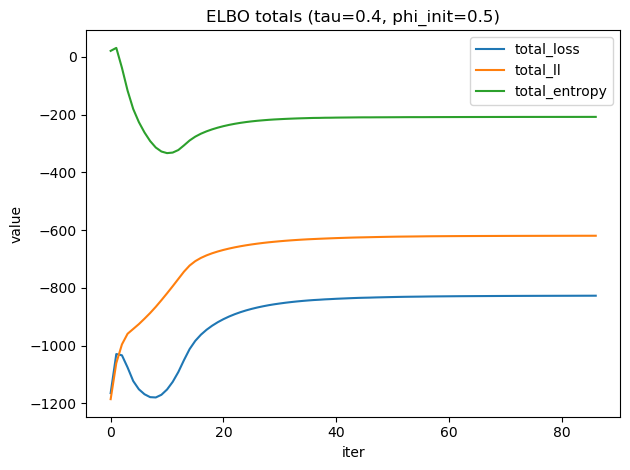

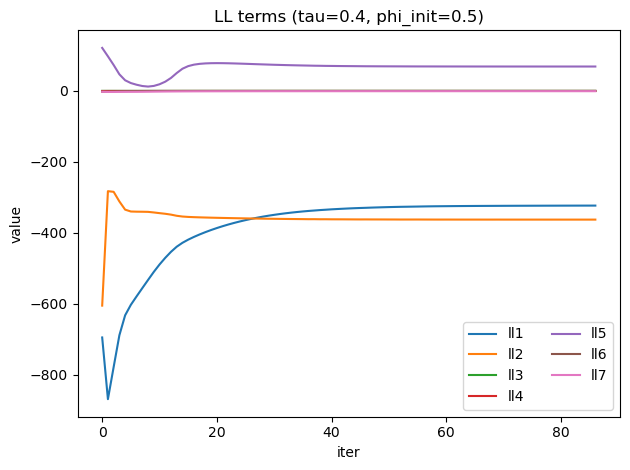

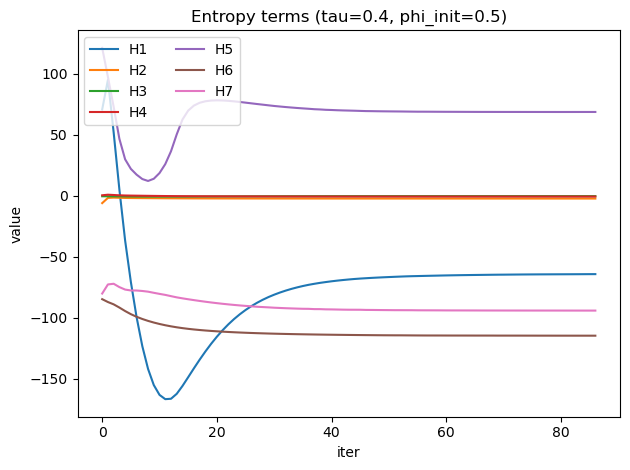

VI debug loop:  87%|████████▋ | 87/100 [3:51:02<01:27,  6.71s/it]


Iter 88/100 | mu_lambda_beta=7.9361 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.1216 | lambda_b2=881.6576
  E[phi]=1.4734 | ||mu_W||=44.2481 | min_eig_VX=7.839e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.7183 | total_ll=-619.1143 | total_entropy=-207.6040
  relative change in total_loss: 5.4778e-03


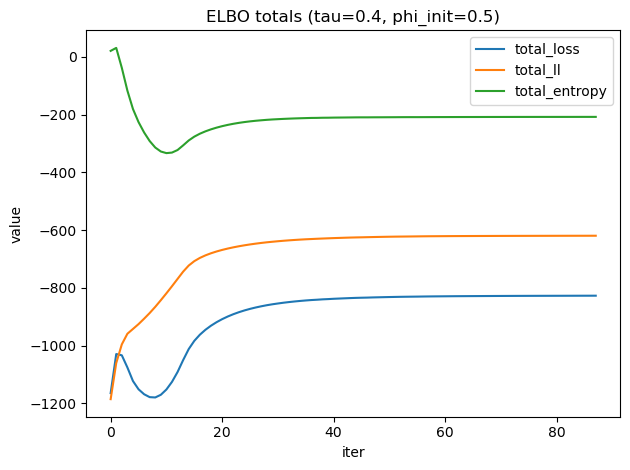

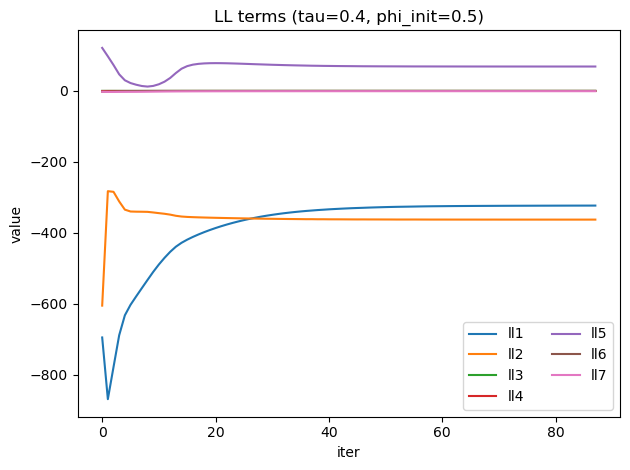

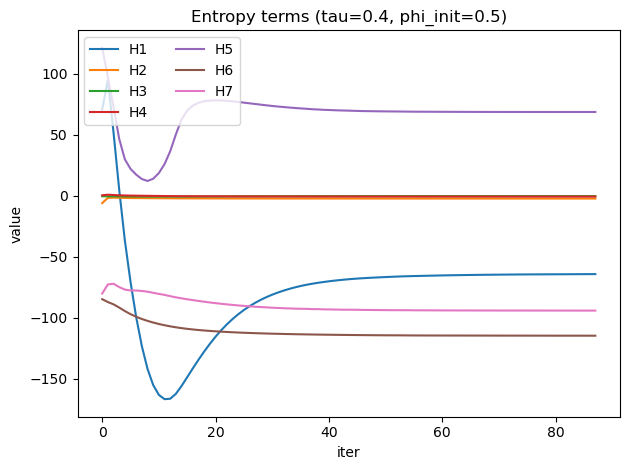

VI debug loop:  88%|████████▊ | 88/100 [3:51:11<01:27,  7.29s/it]


Iter 89/100 | mu_lambda_beta=7.9363 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.2262 | lambda_b2=881.5536
  E[phi]=1.4735 | ||mu_W||=44.2498 | min_eig_VX=7.834e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.6841 | total_ll=-619.0816 | total_entropy=-207.6025
  relative change in total_loss: 4.1344e-03


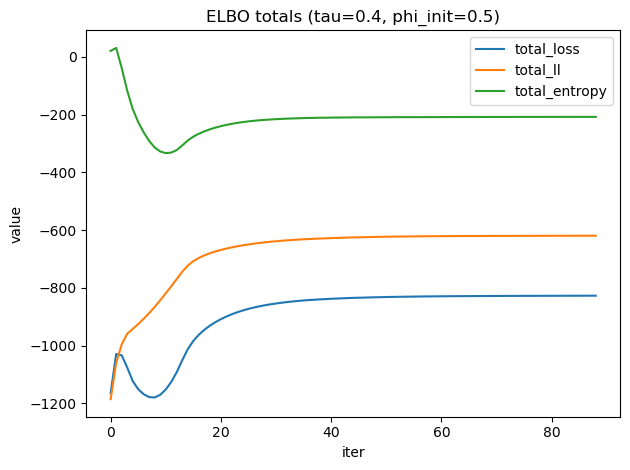

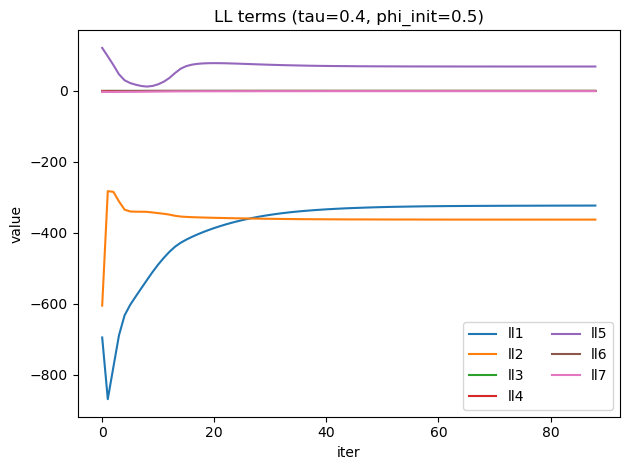

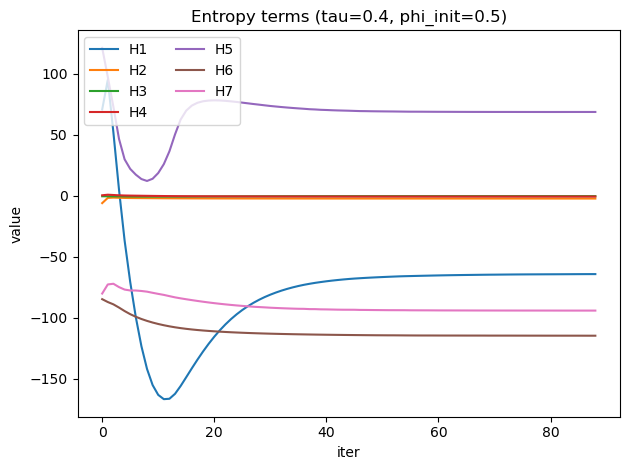

VI debug loop:  89%|████████▉ | 89/100 [3:51:18<01:19,  7.27s/it]


Iter 90/100 | mu_lambda_beta=7.9364 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.3247 | lambda_b2=881.4750
  E[phi]=1.4735 | ||mu_W||=44.2515 | min_eig_VX=7.833e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.6418 | total_ll=-619.0550 | total_entropy=-207.5869
  relative change in total_loss: 5.1091e-03


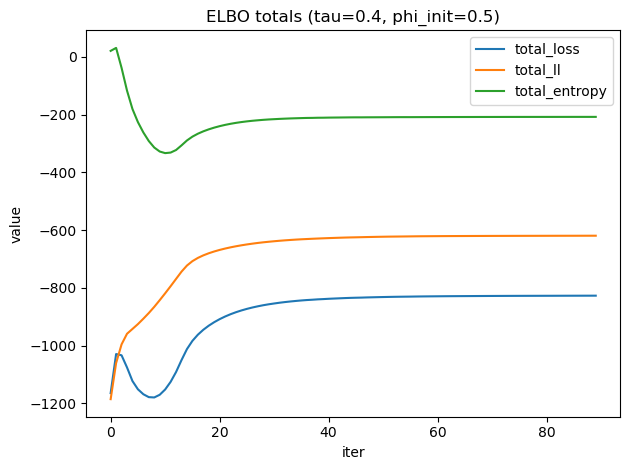

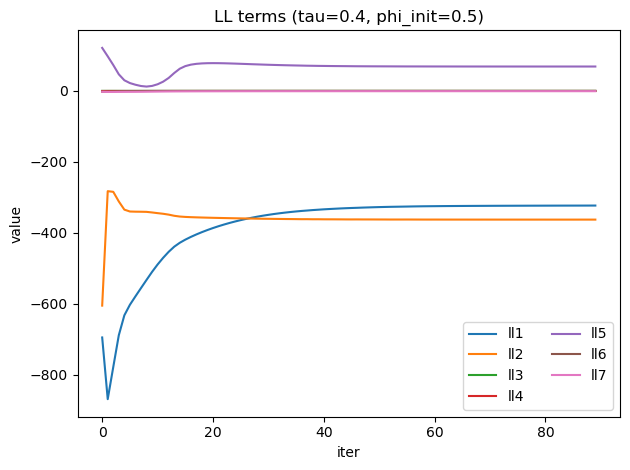

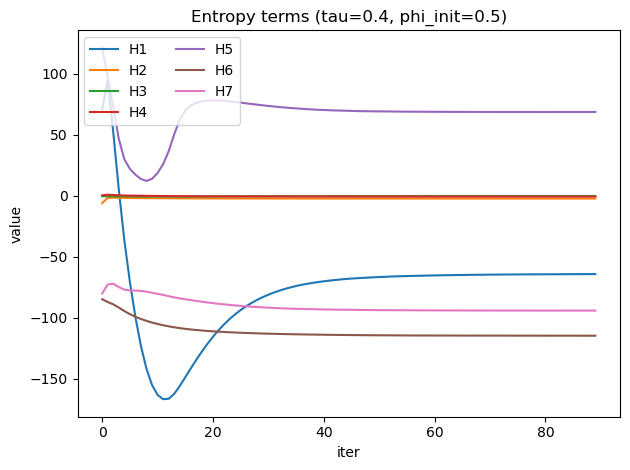

VI debug loop:  90%|█████████ | 90/100 [3:51:23<01:05,  6.53s/it]


Iter 91/100 | mu_lambda_beta=7.9365 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.4229 | lambda_b2=881.4193
  E[phi]=1.4735 | ||mu_W||=44.2527 | min_eig_VX=7.832e-03 | min_eig_VS=2.280e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.6052 | total_ll=-619.0270 | total_entropy=-207.5783
  relative change in total_loss: 4.4301e-03


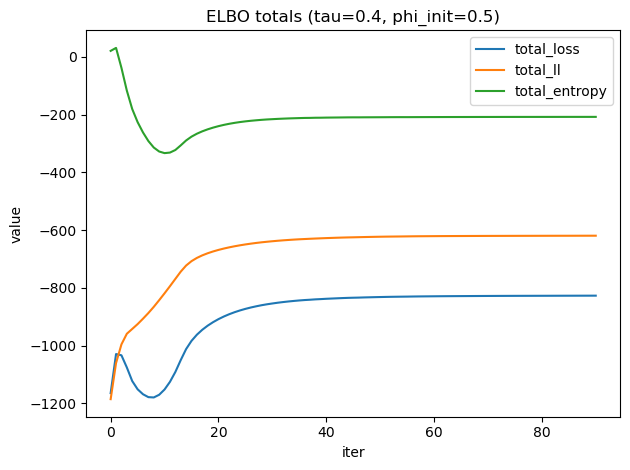

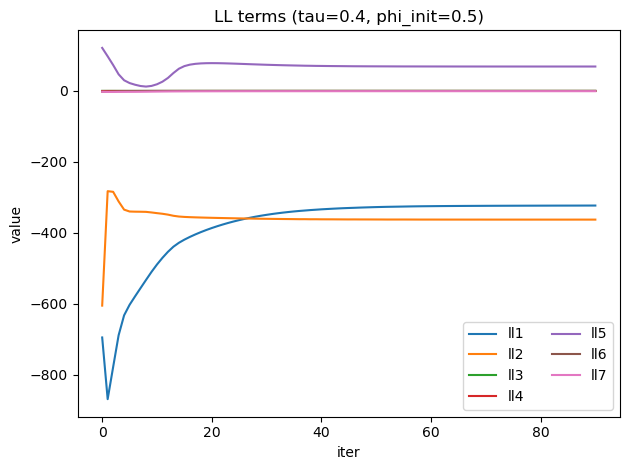

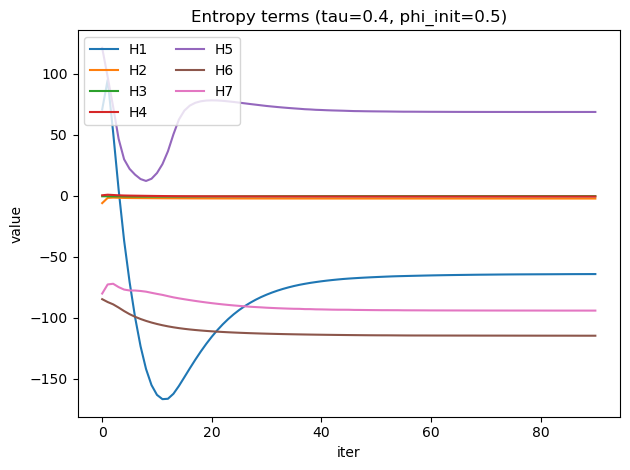

VI debug loop:  91%|█████████ | 91/100 [3:51:30<00:58,  6.53s/it]


Iter 92/100 | mu_lambda_beta=7.9367 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.5148 | lambda_b2=881.3533
  E[phi]=1.4735 | ||mu_W||=44.2541 | min_eig_VX=7.830e-03 | min_eig_VS=2.279e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.5723 | total_ll=-619.0054 | total_entropy=-207.5669
  relative change in total_loss: 3.9873e-03


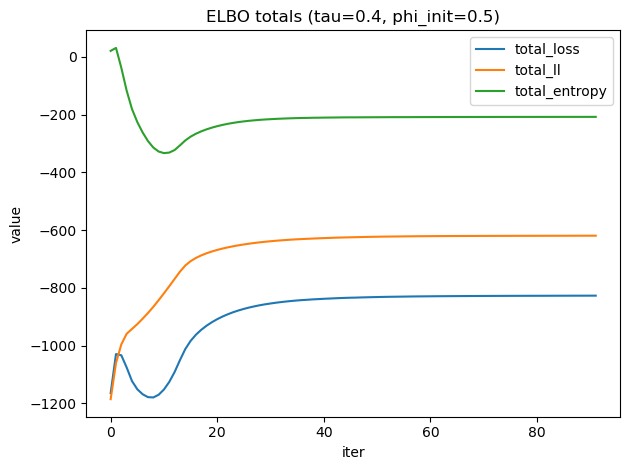

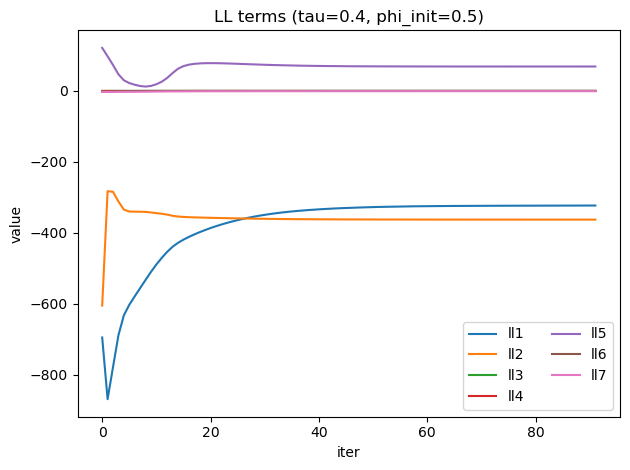

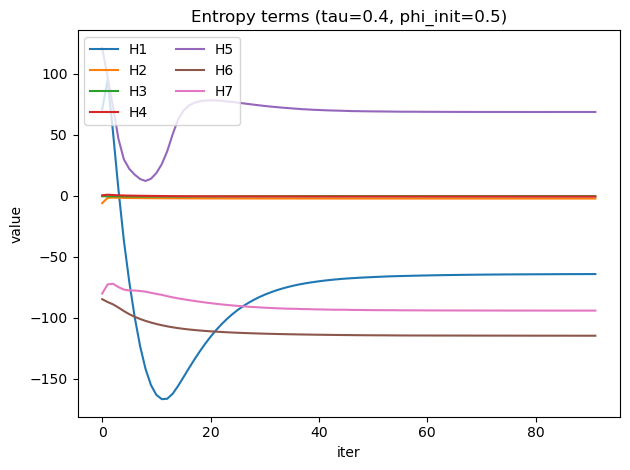

VI debug loop:  92%|█████████▏| 92/100 [3:51:34<00:47,  5.94s/it]


Iter 93/100 | mu_lambda_beta=7.9368 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.6023 | lambda_b2=881.3047
  E[phi]=1.4735 | ||mu_W||=44.2553 | min_eig_VX=7.829e-03 | min_eig_VS=2.279e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.5446 | total_ll=-618.9884 | total_entropy=-207.5562
  relative change in total_loss: 3.3524e-03


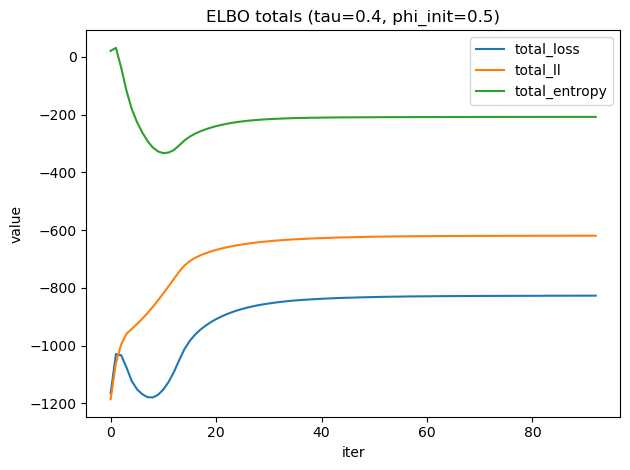

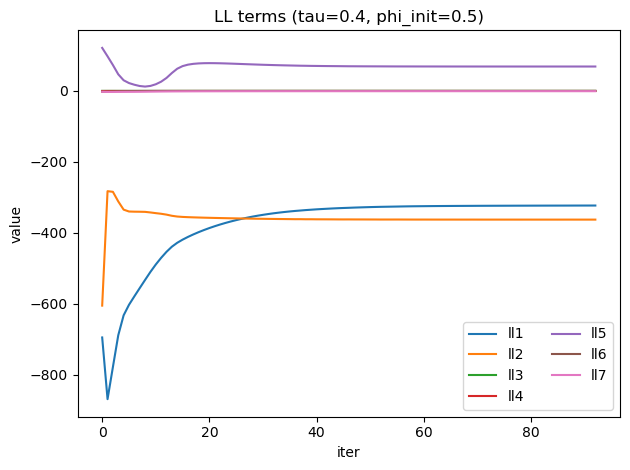

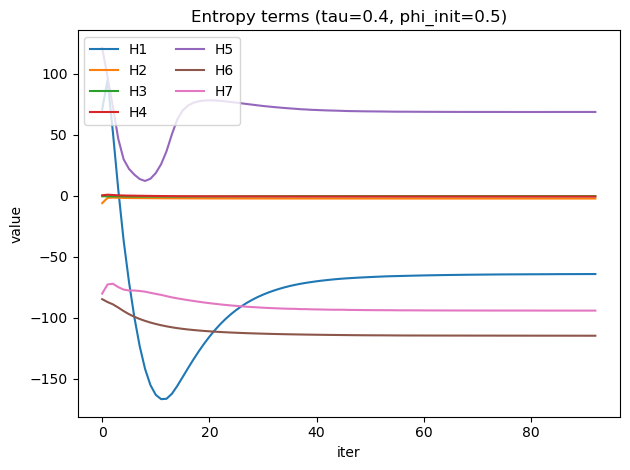

VI debug loop:  93%|█████████▎| 93/100 [3:51:39<00:39,  5.68s/it]


Iter 94/100 | mu_lambda_beta=7.9368 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.6851 | lambda_b2=881.2650
  E[phi]=1.4735 | ||mu_W||=44.2565 | min_eig_VX=7.829e-03 | min_eig_VS=2.279e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.5145 | total_ll=-618.9699 | total_entropy=-207.5446
  relative change in total_loss: 3.6331e-03


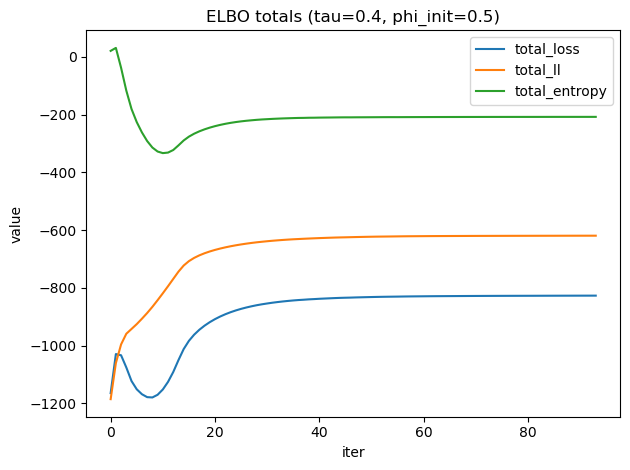

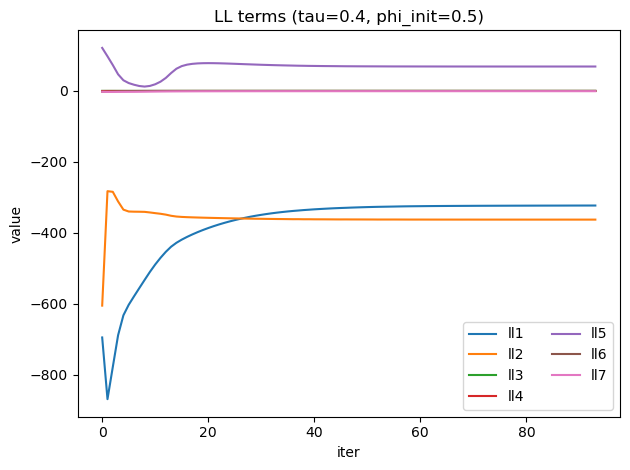

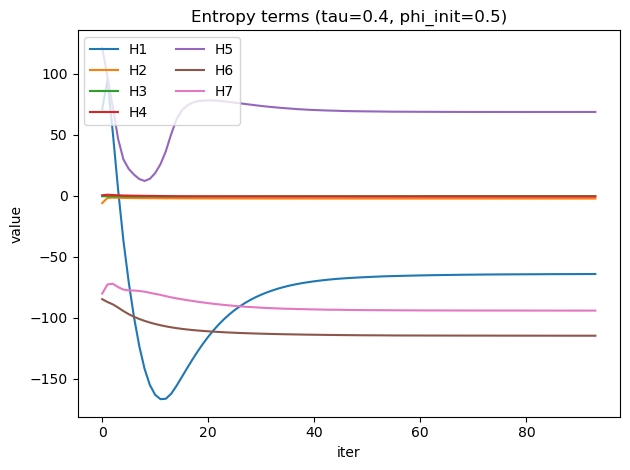

VI debug loop:  94%|█████████▍| 94/100 [3:51:45<00:34,  5.71s/it]


Iter 95/100 | mu_lambda_beta=7.9369 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.7642 | lambda_b2=881.2230
  E[phi]=1.4735 | ||mu_W||=44.2577 | min_eig_VX=7.828e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.4819 | total_ll=-618.9509 | total_entropy=-207.5310
  relative change in total_loss: 3.9434e-03


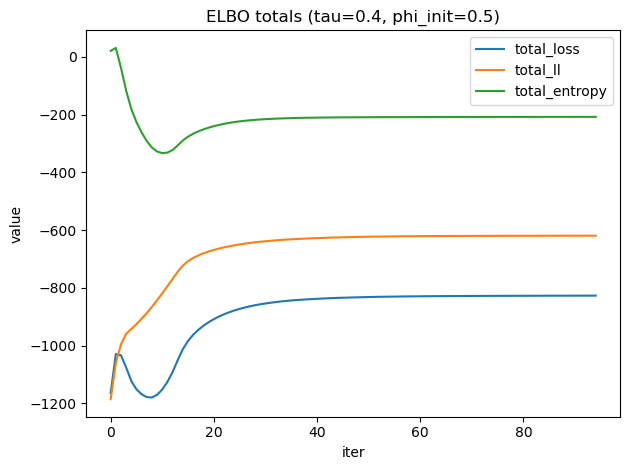

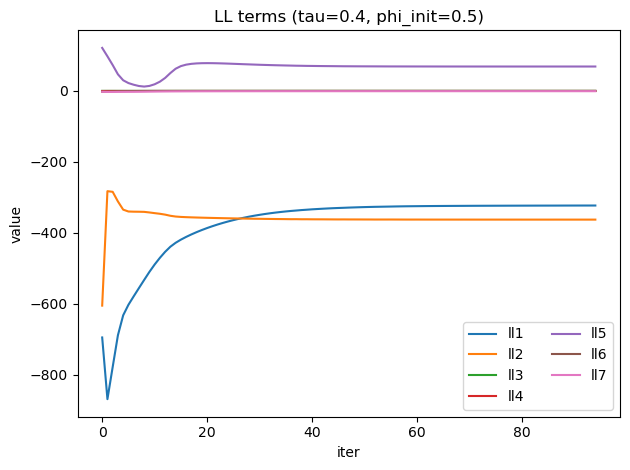

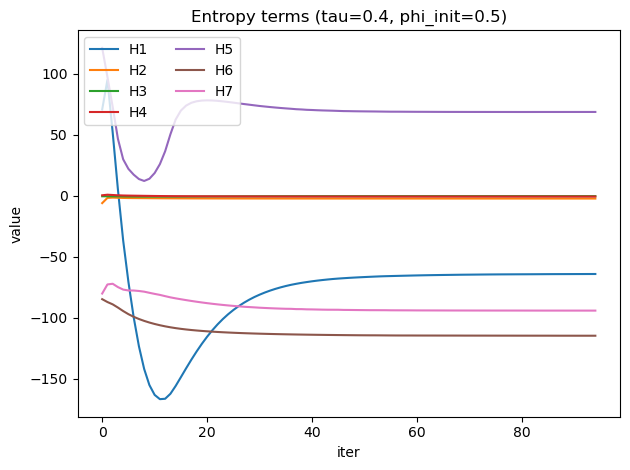

VI debug loop:  95%|█████████▌| 95/100 [3:51:50<00:28,  5.66s/it]


Iter 96/100 | mu_lambda_beta=7.9370 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.8423 | lambda_b2=881.1830
  E[phi]=1.4736 | ||mu_W||=44.2589 | min_eig_VX=7.828e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.4512 | total_ll=-618.9313 | total_entropy=-207.5198
  relative change in total_loss: 3.7220e-03


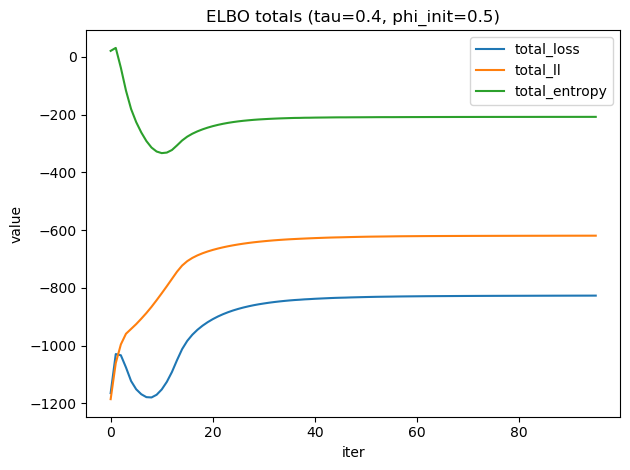

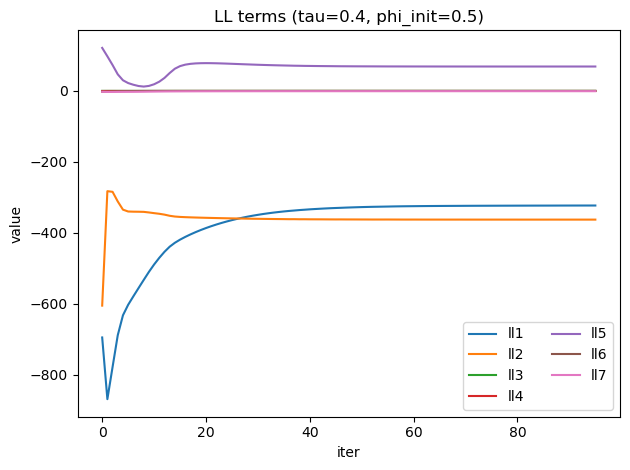

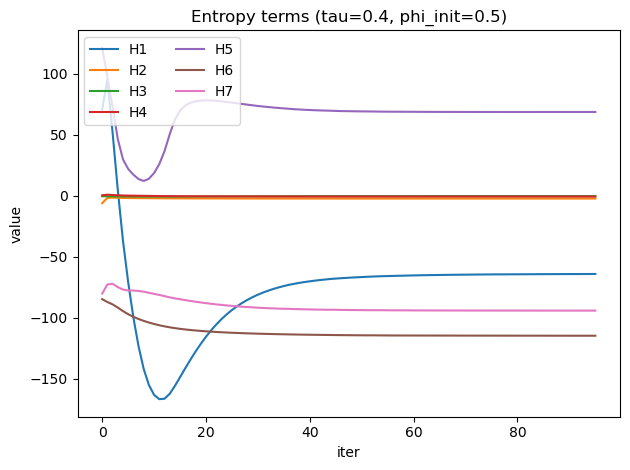

VI debug loop:  96%|█████████▌| 96/100 [3:51:56<00:22,  5.56s/it]


Iter 97/100 | mu_lambda_beta=7.9370 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.9177 | lambda_b2=881.1390
  E[phi]=1.4736 | ||mu_W||=44.2599 | min_eig_VX=7.826e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.4243 | total_ll=-618.9119 | total_entropy=-207.5125
  relative change in total_loss: 3.2495e-03


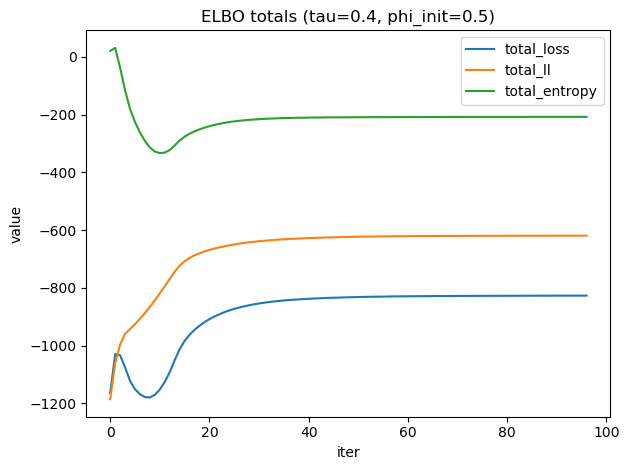

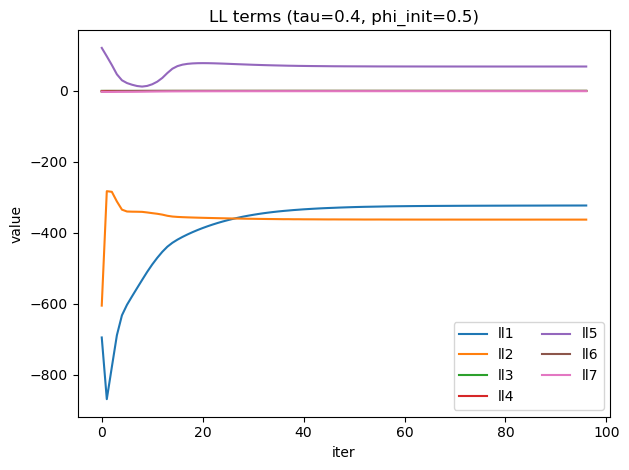

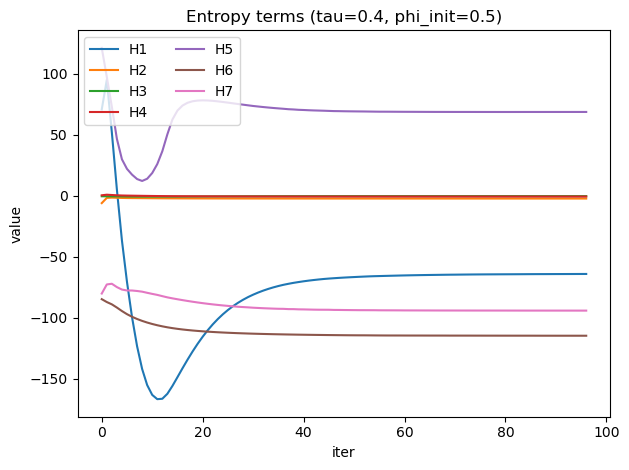

VI debug loop:  97%|█████████▋| 97/100 [3:52:01<00:16,  5.52s/it]


Iter 98/100 | mu_lambda_beta=7.9371 | sigmasq_lambda_beta=0.0102 | lambda_b1=1244.9886 | lambda_b2=881.0924
  E[phi]=1.4736 | ||mu_W||=44.2609 | min_eig_VX=7.825e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.3997 | total_ll=-618.8933 | total_entropy=-207.5064
  relative change in total_loss: 2.9763e-03


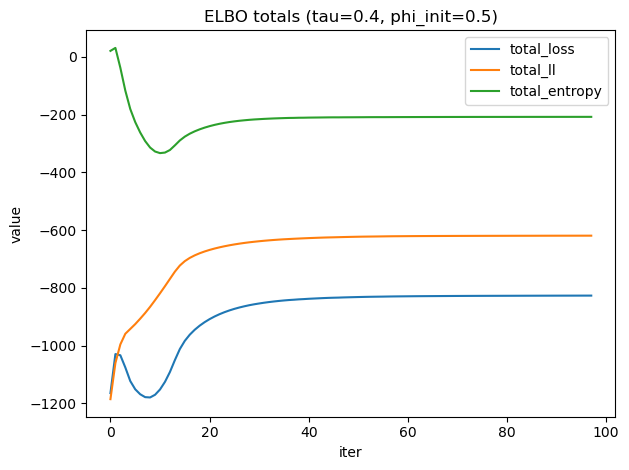

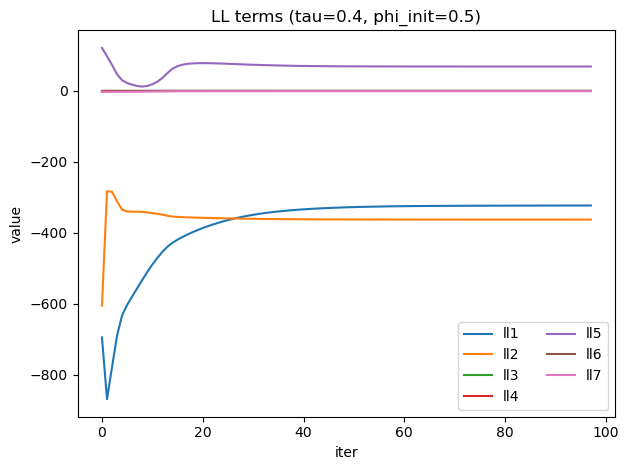

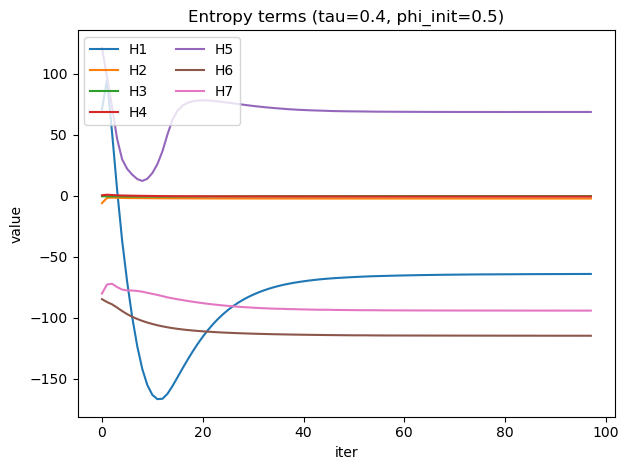

VI debug loop:  98%|█████████▊| 98/100 [3:52:07<00:10,  5.50s/it]


Iter 99/100 | mu_lambda_beta=7.9372 | sigmasq_lambda_beta=0.0102 | lambda_b1=1245.0552 | lambda_b2=881.0486
  E[phi]=1.4736 | ||mu_W||=44.2619 | min_eig_VX=7.824e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.3719 | total_ll=-618.8688 | total_entropy=-207.5031
  relative change in total_loss: 3.3605e-03


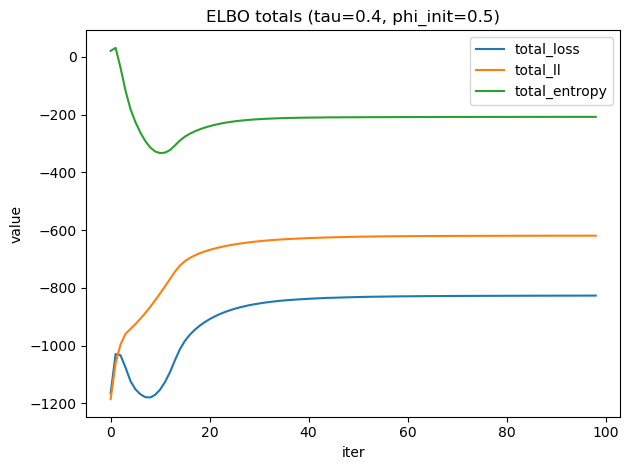

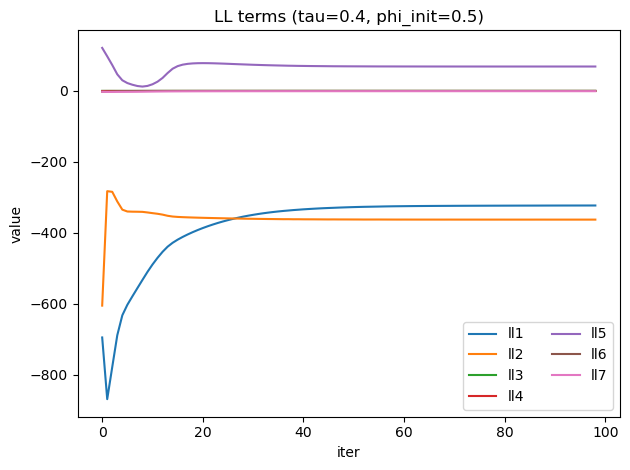

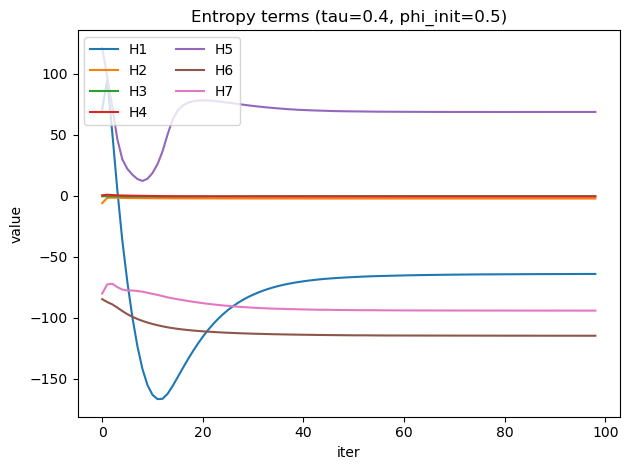

VI debug loop:  99%|█████████▉| 99/100 [3:52:13<00:05,  5.85s/it]


Iter 100/100 | mu_lambda_beta=7.9373 | sigmasq_lambda_beta=0.0102 | lambda_b1=1245.1189 | lambda_b2=880.9911
  E[phi]=1.4736 | ||mu_W||=44.2629 | min_eig_VX=7.821e-03 | min_eig_VS=2.278e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-826.3428 | total_ll=-618.8377 | total_entropy=-207.5050
  relative change in total_loss: 3.5305e-03


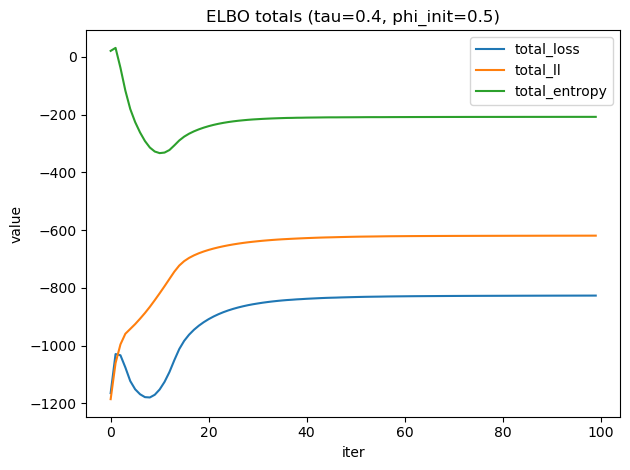

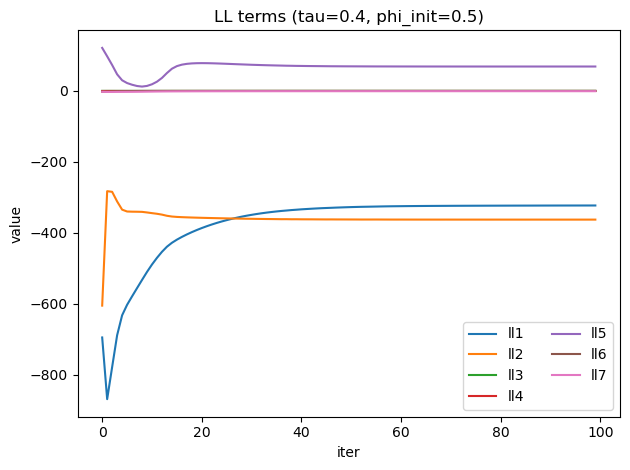

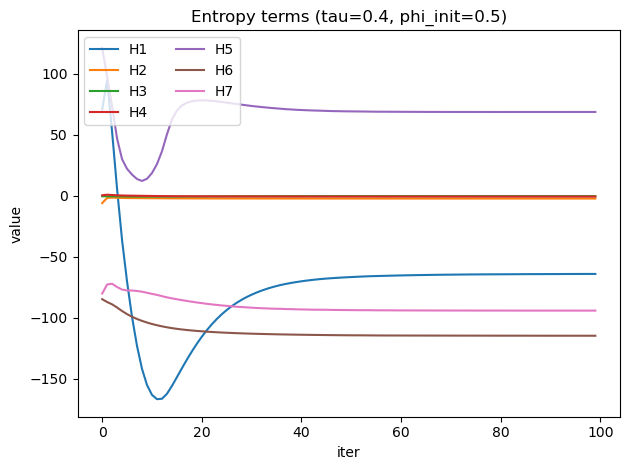

VI debug loop: 100%|██████████| 100/100 [3:52:21<00:00, 139.42s/it]


In [10]:
# ============================================================
# NOTEBOOK CELL: VI core loop + ELBO term debugging (NO funcs)
# Paste/run AFTER your data-load cell that defines:
#   X, Y, Dist, n_blocks, n_locations, device,
#   perm_matrix_x, perm_matrix_s, prior_parameters
# ============================================================

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

from revised_elbo import vi_piX, vi_piS
from utils import nearest_pd_torch, compute_q_phi, round_to_perm

# -----------------------
# User-tunable knobs
# -----------------------
n_iter = 100

tau_X = 0.4
tau_S = 0.4

phi_init = 0.5
n_steps = 50
n_phi_samples = 120
n_piX_sample = 50
n_piS_sample = 50

lr_piX = 0.01
lr_piS = 0.01

VX_ub = 0.6
VS_ub = 0.6

plot_every = 1   # set 5/10 if too slow
seed = 522
torch.manual_seed(seed)

# -----------------------
# Switches (edit freely)
# -----------------------
fix_piX = False
fix_piS = False
fix_mu_lambda_beta = False
fix_sigmasq_lambda_beta = False
fix_lambda_b1 = False
fix_lambda_b2 = False
fix_mu_W = False
fix_Sigma_W = False
fix_mean_Rphi_inv = False

# -----------------------
# Priors (from your dict)
# -----------------------
a1 = prior_parameters["a1"]
b1 = prior_parameters["b1"]
a2 = prior_parameters["a2"]
b2 = prior_parameters["b2"]
eta_X_sq = prior_parameters["eta_X_sq"]
eta_S_sq = prior_parameters["eta_S_sq"]
mu_beta = prior_parameters["mu_beta"]
sigmasq_beta = prior_parameters["sigmasq_beta"]
phi_prior_lb = torch.as_tensor(prior_parameters["phi_prior_lb"], device=device)
phi_prior_ub = torch.as_tensor(prior_parameters["phi_prior_ub"], device=device)

# -----------------------
# Fixed defaults (only used if fix_* = True)
# -----------------------
mu_lambda_beta_fixed = torch.tensor(0.1, device=device)
sigmasq_lambda_beta_fixed = torch.tensor(0.1, device=device)

# your example: ((B*n_i)*0.5 + 0.1)*5
lambda_b1_fixed = torch.tensor(((n_blocks * n_locations) * 0.5 + 0.1) * 5.0, device=device)
lambda_b2_fixed = torch.tensor(0.5, device=device)

M_X_star_fixed = perm_matrix_x.T
M_S_star_fixed = perm_matrix_s.T
V_X_star_fixed = torch.eye(n_locations, n_locations, device=device)
V_S_star_fixed = torch.eye(n_locations, n_locations, device=device)

mean_Rphi_inv_fixed = torch.linalg.inv(torch.exp(-4.0 * Dist))

# -----------------------
# Initialize state
# -----------------------
mu_lambda_beta = torch.tensor(0.1, device=device)
sigmasq_lambda_beta = torch.tensor(0.1, device=device)

mu_W = torch.zeros(n_blocks, n_locations, device=device)
Sigma_W = torch.eye(n_blocks * n_locations, device=device)

Rphi = torch.exp(-(1.0 / phi_init) * Dist)
mean_Rphi_inv = torch.linalg.inv(nearest_pd_torch(Rphi, epsilon=0.01)).to(device)

lambda_a1 = n_blocks * n_locations * 0.5 + a1
lambda_b1 = torch.tensor(0.5, device=device)
lambda_a2 = n_blocks * n_locations * 0.5 + a2
lambda_b2 = torch.tensor(0.5, device=device)

# -----------------------
# Initialize pi models + opt
# -----------------------
model_piX = vi_piX(n_locations=n_locations).to(device)
model_piS = vi_piS(n_locations=n_locations, n_blocks=n_blocks).to(device)

M_X_star = model_piX.current_M_X_star.clone().data.to(device)
V_X_star = model_piX.current_V_X_star.clone().data.to(device)
M_S_star = model_piS.current_M_S_star.clone().data.to(device)
V_S_star = model_piS.current_V_S_star.clone().data.to(device)

# Start from the true perms (as in your call example)
M_X_star = M_X_star_fixed.clone()
M_S_star = M_S_star_fixed.clone()
V_X_star = V_X_star_fixed.clone()
V_S_star = V_S_star_fixed.clone()

optimizer_piX = optim.AdamW(model_piX.parameters(), lr=lr_piX, weight_decay=1e-2)
optimizer_piS = optim.AdamW(model_piS.parameters(), lr=lr_piS, weight_decay=1e-2)

# logits matrices for entropy 6/7 (overwritten if pi models update)
V_X = torch.zeros(n_locations, n_locations, device=device)
V_S = torch.zeros(n_locations, n_locations, device=device)

# true perms for correctness printing
pi_X_true = perm_matrix_x.T
pi_S_true = perm_matrix_s.T

# -----------------------
# ELBO storage arrays
# -----------------------
def _nanvec():
    return np.full(n_iter, np.nan, dtype=np.float64)

elbo = {
    "ll1": _nanvec(), "ll2": _nanvec(), "ll3": _nanvec(), "ll4": _nanvec(),
    "ll5": _nanvec(), "ll6": _nanvec(), "ll7": _nanvec(), "total_ll": _nanvec(),
    "H1": _nanvec(), "H2": _nanvec(), "H3": _nanvec(), "H4": _nanvec(),
    "H5": _nanvec(), "H6": _nanvec(), "H7": _nanvec(), "total_entropy": _nanvec(),
    "total_loss": _nanvec(),
}

# optional extra diagnostics to spot blowups
diag = {
    "mean_phi": _nanvec(),
    "mean_log_q_phi": _nanvec(),
    "min_eig_VX_minus_MtM": _nanvec(),
    "min_eig_VS_minus_MtM": _nanvec(),
    "muW_norm": _nanvec(),
    "SigmaW_logdet": _nanvec(),
}

# -----------------------
# Plot helper (inline)
# -----------------------
def _plot_elbo(upto, suffix=""):
    k = upto + 1

    plt.figure()
    plt.plot(elbo["total_loss"][:k], label="total_loss")
    plt.plot(elbo["total_ll"][:k], label="total_ll")
    plt.plot(elbo["total_entropy"][:k], label="total_entropy")
    plt.legend()
    plt.title(f"ELBO totals {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    plt.figure()
    for nm in ["ll1","ll2","ll3","ll4","ll5","ll6","ll7"]:
        plt.plot(elbo[nm][:k], label=nm)
    plt.legend(ncol=2)
    plt.title(f"LL terms {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    plt.figure()
    for nm in ["H1","H2","H3","H4","H5","H6","H7"]:
        plt.plot(elbo[nm][:k], label=nm)
    plt.legend(ncol=2)
    plt.title(f"Entropy terms {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()


# IMPORTANT: separate prev_loss for each inner optimizer loop
prev_loss_piX = None
prev_loss_piS = None

# ============================================================
# MAIN VI LOOP (step-by-step; you can interrupt any time)
# ============================================================
for it in tqdm(range(n_iter), desc="VI debug loop"):
    # -----------------------
    # sigmasq_lambda_beta
    # -----------------------
    if not fix_sigmasq_lambda_beta:
        X_V_X_star_X = torch.einsum("bi,ij,bj->b", X, V_X_star, X).sum()
        sigmasq_lambda_beta = 1.0 / (((lambda_a2 * X_V_X_star_X) / lambda_b2) + (1.0 / sigmasq_beta))
    else:
        sigmasq_lambda_beta = sigmasq_lambda_beta_fixed

    # -----------------------
    # mu_lambda_beta
    # -----------------------
    if not fix_mu_lambda_beta:
        residual = Y - (M_S_star @ mu_W.T).T
        X_M_X_star_residual = torch.einsum("bi,ij,bj->b", X, M_X_star.T, residual).sum()
        mu_lambda_beta = sigmasq_lambda_beta * ((lambda_a2 / lambda_b2) * X_M_X_star_residual + mu_beta / sigmasq_beta)
    else:
        mu_lambda_beta = mu_lambda_beta_fixed

    # -----------------------
    # lambda_b1
    # -----------------------
    if not fix_lambda_b1:
        mu_W_flat = mu_W.flatten()
        V_W = Sigma_W + torch.outer(mu_W_flat, mu_W_flat)
        lambda_b1 = 0.5 * (torch.trace(mean_Rphi_inv @ V_W)) + b1
    else:
        lambda_b1 = lambda_b1_fixed

    # -----------------------
    # lambda_b2 (+ eigen diagnostics)
    # -----------------------
    if not fix_lambda_b2:
        res = Y - mu_lambda_beta * (M_X_star @ X.T).T - (M_S_star @ mu_W.T).T
        term = torch.trace(res.T @ res)
        term = term + mu_lambda_beta ** 2 * torch.trace(X @ (V_X_star - M_X_star.T @ M_X_star) @ X.T)
        min_eig_VX = torch.min(torch.linalg.eigvalsh(V_X_star - M_X_star.T @ M_X_star))
        term = term + sigmasq_lambda_beta * torch.trace(X @ V_X_star @ X.T)
        term = term + torch.trace(mu_W @ (V_S_star - M_S_star.T @ M_S_star) @ mu_W.T)
        min_eig_VS = torch.min(torch.linalg.eigvalsh(V_S_star - M_S_star.T @ M_S_star))
        term = term + torch.trace(torch.block_diag(*[V_S_star] * n_blocks) @ Sigma_W)
        lambda_b2 = 0.5 * term + b2
    else:
        min_eig_VX = torch.tensor(float("nan"), device=device)
        min_eig_VS = torch.tensor(float("nan"), device=device)
        lambda_b2 = lambda_b2_fixed

    # -----------------------
    # Sigma_W
    # -----------------------
    if not fix_Sigma_W:
        term1 = (lambda_a2 / lambda_b2) * torch.block_diag(*[V_S_star] * n_blocks)
        term2 = (lambda_a1 / lambda_b1) * mean_Rphi_inv
        Sigma_W_inv = term1 + term2
        Sigma_W_inv = (Sigma_W_inv + Sigma_W_inv.T) / 2
        eigvals, eigvecs = torch.linalg.eigh(Sigma_W_inv)
        eigvals_clamped = torch.clamp(eigvals, min=1e-3)
        Sigma_W = eigvecs @ torch.diag(1/eigvals_clamped) @ eigvecs.T
        #Sigma_W = torch.linalg.pinv(Sigma_W_inv, hermitian=True, rtol=1e-4)
        Sigma_W = (Sigma_W + Sigma_W.T) / 2

    # -----------------------
    # mu_W
    # -----------------------
    if not fix_mu_W:
        mu_W = (lambda_a2 / lambda_b2) * (
            Sigma_W @ (M_S_star.T @ Y.T - mu_lambda_beta * M_S_star.T @ M_X_star @ X.T).T.flatten()
        ).reshape(n_blocks, n_locations)

    # -----------------------
    # mean_Rphi_inv (importance sampling)
    # -----------------------
    if not fix_mean_Rphi_inv:
        phi_samples = torch.rand(n_phi_samples, device=device) * (phi_prior_ub - phi_prior_lb) + phi_prior_lb
        q_phi_values = [compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1) for phi in phi_samples]
        logits = torch.tensor([q_phi_values[i][0] for i in range(n_phi_samples)], device=device)
        w = torch.nn.functional.softmax(logits, dim=0)

        Rphi_inv_sum = torch.zeros_like(Dist)
        phi_sum = torch.tensor(0.0, device=device)
        w_sum = torch.tensor(0.0, device=device)
        log_q_sum = torch.tensor(0.0, device=device)

        for i in range(n_phi_samples):
            if w[i] > 1e-5:
                Rphi_inv_sum = Rphi_inv_sum + w[i] * q_phi_values[i][1]
                w_sum = w_sum + w[i]
                phi_sum = phi_sum + w[i] * phi_samples[i]
                log_q_sum = log_q_sum + w[i] * q_phi_values[i][0]

        mean_Rphi_inv = Rphi_inv_sum / w_sum
        mean_phi = phi_sum / w_sum
        mean_log_q_phi = log_q_sum / w_sum
    else:
        mean_Rphi_inv = mean_Rphi_inv_fixed
        mean_phi = torch.tensor(phi_init, device=device)
        mean_log_q_phi = torch.tensor(0.0, device=device)

    # -----------------------
    # piX update
    # -----------------------
    if not fix_piX:
        prev = prev_loss_piX
        for step in range(n_steps):
            optimizer_piX.zero_grad()
            loss_piX = model_piX(
                Y, X, mu_lambda_beta, sigmasq_lambda_beta, M_S_star, mu_W,
                eta_X_sq, lambda_a2, lambda_b2, tau_X,
                n_piX_sample, VX_ub=VX_ub, seed=seed
            )
            loss_piX.backward()
            optimizer_piX.step()
            if prev is not None and abs(prev - loss_piX.item()) < 1e-4:
                break
            prev = loss_piX.item()
        prev_loss_piX = prev

        M_X_star = model_piX.current_M_X_star.clone().data
        V_X_star = model_piX.current_V_X_star.clone().data
        V_X = model_piX.VX.clone().data
    else:
        M_X_star = M_X_star_fixed
        V_X_star = V_X_star_fixed
        V_X = torch.zeros(n_locations, n_locations, device=device)

    # -----------------------
    # piS update
    # -----------------------
    if not fix_piS:
        prev = prev_loss_piS
        for step in range(n_steps):
            optimizer_piS.zero_grad()
            loss_piS = model_piS(
                Y, X, mu_lambda_beta, M_X_star, lambda_a2, lambda_b2,
                mu_W, Sigma_W, eta_S_sq, tau_S,
                n_piS_sample, VS_ub=VS_ub, seed=seed
            )
            loss_piS.backward()
            optimizer_piS.step()
            if prev is not None and abs(prev - loss_piS.item()) < 1e-4:
                break
            prev = loss_piS.item()
        prev_loss_piS = prev

        M_S_star = model_piS.current_M_S_star.clone().data
        V_S_star = model_piS.current_V_S_star.clone().data
        V_S = model_piS.VS.clone().data
    else:
        M_S_star = M_S_star_fixed
        V_S_star = V_S_star_fixed
        V_S = torch.zeros(n_locations, n_locations, device=device)

    # -----------------------
    # Print iteration summary
    # -----------------------
    print(
        f"\nIter {it+1}/{n_iter} | mu_lambda_beta={mu_lambda_beta.item():.4f} "
        f"| sigmasq_lambda_beta={sigmasq_lambda_beta.item():.4f} "
        f"| lambda_b1={lambda_b1.item():.4f} | lambda_b2={lambda_b2.item():.4f}"
    )
    print(
        f"  E[phi]={mean_phi.item():.4f} | ||mu_W||={torch.norm(mu_W).item():.4f} "
        f"| min_eig_VX={min_eig_VX.item():.3e} | min_eig_VS={min_eig_VS.item():.3e}"
    )

    # permutation diagnostics
    try:
        est_perm_piX = round_to_perm(M_X_star.detach().cpu().numpy())
        correct_x = torch.sum(torch.tensor(est_perm_piX, device=device) * pi_X_true)
        print(f"  correct piX entries: {int(correct_x.item())}")
    except Exception:
        pass

    try:
        est_perm_piS = round_to_perm(M_S_star.detach().cpu().numpy())
        correct_s = torch.sum(torch.tensor(est_perm_piS, device=device) * pi_S_true)
        print(f"  correct piS entries: {int(correct_s.item())}")
    except Exception:
        pass

    # ============================================================
    # ELBO DEBUG (store terms each iteration)
    # ============================================================
    elbo_ll_term1 = - (a2 + 0.5 * (n_blocks * n_locations) + 1) * (
        torch.log(torch.as_tensor(lambda_b2, device=device)) - torch.digamma(torch.as_tensor(lambda_a2, device=device))
    )

    resid = Y - mu_lambda_beta * (M_X_star @ X.T).T - (M_S_star @ mu_W.T).T
    resid_sq = torch.trace(resid.T @ resid)
    resid_sq = resid_sq + mu_lambda_beta ** 2 * torch.trace(X @ (V_X_star - M_X_star.T @ M_X_star) @ X.T)
    resid_sq = resid_sq + sigmasq_lambda_beta * torch.trace(X @ V_X_star @ X.T)
    resid_sq = resid_sq + torch.trace(mu_W @ (V_S_star - M_S_star.T @ M_S_star) @ mu_W.T)
    resid_sq = resid_sq + torch.trace(torch.block_diag(*[V_S_star] * n_blocks) @ Sigma_W)

    elbo_ll_term2 = - (b2 + 0.5 * resid_sq) * (lambda_a2 / lambda_b2)
    elbo_ll_term3 = - (b1 * lambda_a1) / lambda_b1
    elbo_ll_term4 = - (mu_lambda_beta ** 2 + sigmasq_lambda_beta) / (2 * sigmasq_beta)
    elbo_ll_term5 = - mean_log_q_phi

    elbo_ll_term6 = model_piX.mean_log_term_sum
    elbo_ll_term7 = model_piS.mean_log_term_sum
    total_ll = elbo_ll_term1 + elbo_ll_term2 + elbo_ll_term3 + elbo_ll_term4 + elbo_ll_term5 + elbo_ll_term6 + elbo_ll_term7

    entropy_term1 = 0.5 * torch.slogdet(Sigma_W)[1]
    entropy_term2 = 0.5 * torch.log(torch.as_tensor(sigmasq_lambda_beta, device=device))

    entropy_term3 = (
        lambda_a1 + torch.log(torch.as_tensor(lambda_b1, device=device)) + torch.lgamma(torch.as_tensor(lambda_a1, device=device))
        - (1 + lambda_a1) * torch.digamma(torch.as_tensor(lambda_a1, device=device))
    )
    entropy_term4 = (
        lambda_a2 + torch.log(torch.as_tensor(lambda_b2, device=device)) + torch.lgamma(torch.as_tensor(lambda_a2, device=device))
        - (1 + lambda_a2) * torch.digamma(torch.as_tensor(lambda_a2, device=device))
    )
    entropy_term5 = - mean_log_q_phi

    entropy_term6 = (n_locations ** 2) * (torch.log(torch.as_tensor(tau_X, device=device))) + 0.5 * torch.log(torch.special.expit(V_X) * (VX_ub - 0.01) + 0.01).sum()
    entropy_term7 = (n_locations ** 2) * ( torch.log(torch.as_tensor(tau_S, device=device))) + 0.5 * torch.log(torch.special.expit(V_S) * (VS_ub - 0.01) + 0.01).sum()
    

    total_entropy = entropy_term1 + entropy_term2 + entropy_term3 + entropy_term4 + entropy_term5 + entropy_term6 + entropy_term7
    total_loss = total_ll + total_entropy

    print(f"[ELBO] total_loss={total_loss.item():.4f} | total_ll={total_ll.item():.4f} | total_entropy={total_entropy.item():.4f}")

    # store ELBO pieces
    elbo["ll1"][it] = float(elbo_ll_term1.detach().cpu().item())
    elbo["ll2"][it] = float(elbo_ll_term2.detach().cpu().item())
    elbo["ll3"][it] = float(elbo_ll_term3.detach().cpu().item())
    elbo["ll4"][it] = float(elbo_ll_term4.detach().cpu().item())
    elbo["ll5"][it] = float(elbo_ll_term5.detach().cpu().item())
    elbo["ll6"][it] = float(elbo_ll_term6.detach().cpu().item())
    elbo["ll7"][it] = float(elbo_ll_term7.detach().cpu().item())
    elbo["total_ll"][it] = float(total_ll.detach().cpu().item())

    elbo["H1"][it] = float(entropy_term1.detach().cpu().item())
    elbo["H2"][it] = float(entropy_term2.detach().cpu().item())
    elbo["H3"][it] = float(entropy_term3.detach().cpu().item())
    elbo["H4"][it] = float(entropy_term4.detach().cpu().item())
    elbo["H5"][it] = float(entropy_term5.detach().cpu().item())
    elbo["H6"][it] = float(entropy_term6.detach().cpu().item())
    elbo["H7"][it] = float(entropy_term7.detach().cpu().item())
    elbo["total_entropy"][it] = float(total_entropy.detach().cpu().item())

    elbo["total_loss"][it] = float(total_loss.detach().cpu().item())
    # relative change in percentage (with small epsilon to avoid div by zero)
    if it > 0:
        rel_change = abs(total_loss.detach().cpu().item() - elbo["total_loss"][it-1]) / (abs(elbo["total_loss"][it-1]) + 1e-8) * 100
        print(f"  relative change in total_loss: {rel_change:.4e}")

    # store diagnostics
    diag["mean_phi"][it] = float(mean_phi.detach().cpu().item())
    diag["mean_log_q_phi"][it] = float(mean_log_q_phi.detach().cpu().item())
    diag["min_eig_VX_minus_MtM"][it] = float(min_eig_VX.detach().cpu().item())
    diag["min_eig_VS_minus_MtM"][it] = float(min_eig_VS.detach().cpu().item())
    diag["muW_norm"][it] = float(torch.norm(mu_W).detach().cpu().item())
    try:
        diag["SigmaW_logdet"][it] = float(torch.slogdet(Sigma_W)[1].detach().cpu().item())
    except Exception:
        diag["SigmaW_logdet"][it] = np.nan

    # plot
    if plot_every and ((it % plot_every) == 0 or it == n_iter - 1):
        _plot_elbo(it, suffix=f"(tau={tau_X}, phi_init={phi_init})")

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(elbo["total_ll"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("VI Optimization: Total Log-Likelihood History")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
(n_locations ** 2) * (torch.log(torch.tensor(tau_X, device=device))) + 0.5 * torch.log(torch.special.expit(V_X) * (VX_ub - 0.01) + 0.01).sum()
    